<!-- CELL 1 (Markdown) -->
 Five CNN + Attention Gate architectures:
   - ResNet18 + Attention Gate
   - DenseNet121 + Attention Gate
   - VGG16 + Attention Gate
   - MobileNetV2 + Attention Gate
   - DenseNet121 + A-PBS-inspired attention (adapted, not a literal reproduction)





In [1]:
# CELL 2

# -----------------------------------------------------------------------
# Imports, reproducibility, device/AMP setup.
# -----------------------------------------------------------------------
import os, sys, json, time, random, hashlib, warnings, platform, shutil
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = False  # we WANT PIL to raise on truncated files (audit)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix
)

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print('Environment')
print(f'  Python        : {platform.python_version()}')
print(f'  PyTorch       : {torch.__version__}')
print(f'  CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU           : {torch.cuda.get_device_name(0)}')
print(f'  Device        : {DEVICE}')
print(f'  AMP enabled   : {USE_AMP}')
print(f'  Seed          : {SEED}')


Environment
  Python        : 3.11.15
  PyTorch       : 2.5.1+cu121
  CUDA available: True
  GPU           : NVIDIA GeForce RTX 2050
  Device        : cuda
  AMP enabled   : True
  Seed          : 42


In [2]:
# CELL 3

# -----------------------------------------------------------------------
# Dataset paths (exact, per project spec) and central config object.
# -----------------------------------------------------------------------
NORMAL_DIR    = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\IIITDNewNormal")
PRINTSCAN_DIR = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\PrintScan")
COGENT_DIR    = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\PrintScan\Cogent")
VISTA_DIR     = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\PrintScan\Vista")

PROJECT_ROOT = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD")
OUT_ROOT     = PROJECT_ROOT / 'outputs'

OUT_DIRS = {
    'manifests'     : OUT_ROOT / 'manifests',
    'audit'         : OUT_ROOT / 'audit',
    'augmentation'  : OUT_ROOT / 'augmentation',
    'checkpoints'   : OUT_ROOT / 'checkpoints',
    'histories'     : OUT_ROOT / 'histories',
    'predictions'   : OUT_ROOT / 'predictions',
    'metrics'       : OUT_ROOT / 'metrics',
    'figures'       : OUT_ROOT / 'figures',
    'tda'           : OUT_ROOT / 'tda',
    'explainability': OUT_ROOT / 'explainability',
    'statistics'    : OUT_ROOT / 'statistics',
    'final'         : OUT_ROOT / 'final',
}
for d in OUT_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

VALID_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

# Label convention (documented, not inferred from filenames)
LABEL_BONA_FIDE = 0
LABEL_ATTACK    = 1
SOURCE_LABEL_POLICY = {
    'IIITDNewNormal': LABEL_BONA_FIDE,
    'PrintScan'      : LABEL_ATTACK,
}

CONFIG = {
    'seed'               : SEED,
    'img_size'           : 224,
    'max_epochs'         : 50,
    'early_stop_patience': 25,
    'lr'                 : 1e-4,
    'weight_decay'       : 1e-4,
    'batch_size'         : 32,
    'train_frac'         : 0.70,
    'val_frac'           : 0.15,
    'test_frac'          : 0.15,
    'target_effective_n' : 25000,
    'label_bona_fide'    : LABEL_BONA_FIDE,
    'label_attack'       : LABEL_ATTACK,
    'score_orientation'  : 'p_attack = P(label=1); higher score = more attack-like',
}

with open(OUT_DIRS['final'] / 'config.json', 'w') as f:
    json.dump({**CONFIG,
               'python_version': platform.python_version(),
               'torch_version' : torch.__version__,
               'cuda_available': torch.cuda.is_available(),
               'gpu_name'      : torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
               'device'        : str(DEVICE)}, f, indent=2)

print('Paths configured:')
for name, p in [('NORMAL_DIR', NORMAL_DIR), ('PRINTSCAN_DIR', PRINTSCAN_DIR),
                ('COGENT_DIR', COGENT_DIR), ('VISTA_DIR', VISTA_DIR)]:
    print(f'  {name:14s}: {p}  (exists={p.exists()})')
print(f'\nOutput root: {OUT_ROOT}')
print('Config saved -> outputs/final/config.json')


Paths configured:
  NORMAL_DIR    : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\IIITDNewNormal  (exists=True)
  PRINTSCAN_DIR : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\PrintScan  (exists=True)
  COGENT_DIR    : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\PrintScan\Cogent  (exists=True)
  VISTA_DIR     : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Raw\IRIS CSD\PrintScan\Vista  (exists=True)

Output root: C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs
Config saved -> outputs/final/config.json


<!-- CELL 4 (Markdown) -->
## Section 1: Programmatic Dataset Audit


In [3]:
# CELL 5

# -----------------------------------------------------------------------
# Recursive file scan: every image under a root, with extension, size,
# parent-folder chain (for later subject-id extraction), and a fast
# content hash used for duplicate detection.
# -----------------------------------------------------------------------
def fast_file_hash(path, chunk_size=65536):
    '''MD5 of file bytes -- fast, adequate for exact-duplicate detection.'''
    h = hashlib.md5()
    try:
        with open(path, 'rb') as f:
            while True:
                chunk = f.read(chunk_size)
                if not chunk:
                    break
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None


def scan_directory(root, source_name):
    '''Recursively walk `root`, return a DataFrame of every valid-extension file.'''
    rows = []
    if not root.exists():
        print(f'  [WARNING] Path does not exist: {root}')
        return pd.DataFrame(rows)

    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            ext = Path(fname).suffix.lower()
            fpath = Path(dirpath) / fname
            rel = fpath.relative_to(root)
            rows.append({
                'path'           : str(fpath),
                'filename'       : fname,
                'extension'      : ext,
                'is_valid_ext'   : ext in VALID_EXTS,
                'relative_parts' : rel.parts,
                'parent_dir'     : str(fpath.parent),
                'source_dataset' : source_name,
                'size_bytes'     : fpath.stat().st_size if fpath.exists() else -1,
            })
    return pd.DataFrame(rows)


print('Scanning directories (this walks the real filesystem)...')
scan_normal    = scan_directory(NORMAL_DIR, 'IIITDNewNormal')
scan_cogent    = scan_directory(COGENT_DIR, 'PrintScan_Cogent')
scan_vista     = scan_directory(VISTA_DIR,  'PrintScan_Vista')

all_scans = pd.concat([scan_normal, scan_cogent, scan_vista], ignore_index=True) \
    if len(scan_normal) or len(scan_cogent) or len(scan_vista) else pd.DataFrame()

print(f'\nRaw file counts (ALL extensions, recursive):')
for name, df in [('IIITDNewNormal', scan_normal), ('PrintScan/Cogent', scan_cogent),
                  ('PrintScan/Vista', scan_vista)]:
    print(f'  {name:20s}: {len(df):6d} files found on disk')

if len(all_scans):
    print(f'\nExtension breakdown (all sources):')
    print(all_scans['extension'].value_counts().to_string())


Scanning directories (this walks the real filesystem)...

Raw file counts (ALL extensions, recursive):
  IIITDNewNormal      :   6022 files found on disk
  PrintScan/Cogent    :   1179 files found on disk
  PrintScan/Vista     :   1197 files found on disk

Extension breakdown (all sources):
extension
.jpg    8398


In [4]:
# CELL 6

# -----------------------------------------------------------------------
# Filter to valid image extensions and compare measured counts against
# the UNVERIFIED priors stated in the project brief.
# -----------------------------------------------------------------------
PRIOR_COUNTS = {
    'IIITDNewNormal': 6022,   # stated prior, NOT authoritative
    'PrintScan'      : 4244,  # stated prior, NOT authoritative
}

if len(all_scans):
    valid_scans = all_scans[all_scans['is_valid_ext']].reset_index(drop=True)
    n_invalid   = len(all_scans) - len(valid_scans)
else:
    valid_scans = pd.DataFrame()
    n_invalid = 0

n_normal  = int((valid_scans['source_dataset'] == 'IIITDNewNormal').sum()) if len(valid_scans) else 0
n_cogent  = int((valid_scans['source_dataset'] == 'PrintScan_Cogent').sum()) if len(valid_scans) else 0
n_vista   = int((valid_scans['source_dataset'] == 'PrintScan_Vista').sum()) if len(valid_scans) else 0
n_printscan = n_cogent + n_vista

print('MEASURED vs PRIOR (unverified) counts:')
print(f'  IIITDNewNormal : measured={n_normal:6d}   prior={PRIOR_COUNTS["IIITDNewNormal"]:6d}   '
      f'delta={n_normal - PRIOR_COUNTS["IIITDNewNormal"]:+6d}')
print(f'  PrintScan      : measured={n_printscan:6d}   prior={PRIOR_COUNTS["PrintScan"]:6d}   '
      f'delta={n_printscan - PRIOR_COUNTS["PrintScan"]:+6d}')
print(f'    - Cogent     : measured={n_cogent:6d}')
print(f'    - Vista      : measured={n_vista:6d}')
print(f'  Non-image files ignored (invalid extension): {n_invalid}')

if n_normal == 0 or n_printscan == 0:
    print('\n[CRITICAL WARNING] One or more source directories produced ZERO valid images.')
    print('This notebook cannot proceed meaningfully until paths are corrected.')
    print('All downstream cells will still run structurally but manifests will be empty/small.')


MEASURED vs PRIOR (unverified) counts:
  IIITDNewNormal : measured=  6022   prior=  6022   delta=    +0
  PrintScan      : measured=  2376   prior=  4244   delta= -1868
    - Cogent     : measured=  1179
    - Vista      : measured=  1197
  Non-image files ignored (invalid extension): 0


In [5]:
# CELL 7

# -----------------------------------------------------------------------
# Corrupted / unreadable image detection: attempt PIL open + verify on
# every candidate file. This can take a while on large datasets; a
# progress bar is shown. Corrupted paths are EXCLUDED from the manifest,
# never silently included.
# -----------------------------------------------------------------------
def check_image_integrity(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.load()
            _ = img.size
        return True, None
    except Exception as e:
        return False, str(e)


corrupted_rows = []
if len(valid_scans):
    print(f'Verifying integrity of {len(valid_scans)} candidate images...')
    integrity_results = []
    for p in tqdm(valid_scans['path'].tolist(), desc='Integrity check'):
        ok, err = check_image_integrity(p)
        integrity_results.append(ok)
        if not ok:
            corrupted_rows.append({'path': p, 'error': err})
    valid_scans['is_readable'] = integrity_results
else:
    valid_scans['is_readable'] = []

n_corrupted = len(corrupted_rows)
print(f'\nCorrupted / unreadable files: {n_corrupted}')
if n_corrupted:
    corrupt_df = pd.DataFrame(corrupted_rows)
    corrupt_df.to_csv(OUT_DIRS['audit'] / 'corrupted_images.csv', index=False)
    print(f'  Saved list -> outputs/audit/corrupted_images.csv')
    print(corrupt_df.head(10).to_string(index=False))

clean_scans = valid_scans[valid_scans['is_readable']].reset_index(drop=True) if len(valid_scans) else pd.DataFrame()
print(f'\nClean, readable images retained: {len(clean_scans)}')


Verifying integrity of 8398 candidate images...


Integrity check:   0%|          | 0/8398 [00:00<?, ?it/s]


Corrupted / unreadable files: 0

Clean, readable images retained: 8398


In [6]:
# CELL 8

# -----------------------------------------------------------------------
# Duplicate detection:
#   (a) exact path duplicates (should be impossible from os.walk, sanity check)
#   (b) exact content duplicates via MD5 hash (within-source AND cross-source)
# Cross-directory duplicates are flagged but NOT silently removed --
# they are reported for manual review since removing images changes
# the labeled dataset composition.
# -----------------------------------------------------------------------
if len(clean_scans):
    print('Computing content hashes for duplicate detection (this may take a while)...')
    hashes = [fast_file_hash(p) for p in tqdm(clean_scans['path'].tolist(), desc='Hashing')]
    clean_scans['content_hash'] = hashes

    path_dupes = clean_scans[clean_scans.duplicated(subset='path', keep=False)]
    print(f'Exact path duplicates (should be 0): {len(path_dupes)}')

    hash_counts = clean_scans['content_hash'].value_counts()
    dup_hashes  = hash_counts[hash_counts > 1].index.tolist()
    dup_rows    = clean_scans[clean_scans['content_hash'].isin(dup_hashes)] \
                    .sort_values('content_hash')

    print(f'Distinct content hashes appearing more than once: {len(dup_hashes)}')
    print(f'Total files involved in content duplication: {len(dup_rows)}')

    cross_source_dupe_groups = 0
    if len(dup_rows):
        for h, grp in dup_rows.groupby('content_hash'):
            if grp['source_dataset'].nunique() > 1:
                cross_source_dupe_groups += 1
        print(f'Duplicate groups spanning MULTIPLE source datasets: {cross_source_dupe_groups}')
        if cross_source_dupe_groups > 0:
            print('  [WARNING] Cross-source duplicate images detected. Review '
                  'outputs/audit/duplicate_groups.csv before trusting label separability.')
        dup_rows.to_csv(OUT_DIRS['audit'] / 'duplicate_groups.csv', index=False)
else:
    print('No clean images available -- skipping duplicate detection.')
    dup_hashes = []
    cross_source_dupe_groups = 0


Computing content hashes for duplicate detection (this may take a while)...


Hashing:   0%|          | 0/8398 [00:00<?, ?it/s]

Exact path duplicates (should be 0): 0
Distinct content hashes appearing more than once: 6
Total files involved in content duplication: 12
Duplicate groups spanning MULTIPLE source datasets: 0


In [50]:
# CELL 9

# -----------------------------------------------------------------------
# Filename pattern audit. We CATEGORIZE observed suffix patterns for
# reporting only -- we never use them to assign labels.
# Patterns explicitly checked per the project brief: c1, c2, n, t, scan*.
# -----------------------------------------------------------------------
import re

PATTERN_DEFS = {
    'suffix_c1'   : re.compile(r'_c1[_.]', re.IGNORECASE),
    'suffix_c2'   : re.compile(r'_c2[_.]', re.IGNORECASE),
    'suffix_n'    : re.compile(r'_n[_.]',  re.IGNORECASE),
    'suffix_t'    : re.compile(r'_t[_.]',  re.IGNORECASE),
    'scan_prefix' : re.compile(r'^scan\d+', re.IGNORECASE),
}

def classify_filename(fname):
    hits = [name for name, rx in PATTERN_DEFS.items() if rx.search(fname)]
    return ','.join(hits) if hits else 'unclassified'

if len(clean_scans):
    clean_scans['filename_pattern'] = clean_scans['filename'].apply(classify_filename)
    pattern_summary = (clean_scans
                        .groupby(['source_dataset', 'filename_pattern'])
                        .size()
                        .reset_index(name='count')
                        .sort_values(['source_dataset', 'count'], ascending=[True, False]))
    print('Filename pattern counts per source dataset:')
    print(pattern_summary.to_string(index=False))
    pattern_summary.to_csv(OUT_DIRS['audit'] / 'filename_pattern_summary.csv', index=False)

    # Suspicious-pattern warning: "_n_" inside PrintScan could mean "normal/live"
    # which would CONTRADICT the PrintScan=attack labeling policy.
    printscan_mask = clean_scans['source_dataset'].isin(['PrintScan_Cogent', 'PrintScan_Vista'])
    n_suspicious = int(clean_scans.loc[printscan_mask, 'filename_pattern']
                        .str.contains('suffix_n').sum())
    


Filename pattern counts per source dataset:
  source_dataset filename_pattern  count
  IIITDNewNormal     unclassified   6022
PrintScan_Cogent      scan_prefix    404
PrintScan_Cogent        suffix_c2    194
PrintScan_Cogent         suffix_n    194
PrintScan_Cogent         suffix_t    194
PrintScan_Cogent        suffix_c1    193
 PrintScan_Vista     unclassified    426
 PrintScan_Vista        suffix_c2    194
 PrintScan_Vista         suffix_t    193
 PrintScan_Vista        suffix_c1    192
 PrintScan_Vista         suffix_n    192


In [52]:
# CELL 10

# -----------------------------------------------------------------------
# Consolidated audit report (JSON) -- the single source of truth for
# "what did we actually find on disk" that a reader can inspect without
# re-running the scan.
# -----------------------------------------------------------------------
audit_report = {
    'measured_counts': {
        'IIITDNewNormal_raw'      : int(len(scan_normal)),
        'PrintScan_Cogent_raw'    : int(len(scan_cogent)),
        'PrintScan_Vista_raw'     : int(len(scan_vista)),
        'IIITDNewNormal_valid_ext': n_normal,
        'PrintScan_Cogent_valid_ext': n_cogent,
        'PrintScan_Vista_valid_ext' : n_vista,
        'clean_readable_total'    : int(len(clean_scans)) if len(clean_scans) else 0,
    },
    'prior_counts_unverified': PRIOR_COUNTS,
    'corrupted_file_count'   : n_corrupted if 'n_corrupted' in dir() else 0,
    'duplicate_hash_groups'  : len(dup_hashes) if 'dup_hashes' in dir() else 0,
    'cross_source_dup_groups': cross_source_dupe_groups if 'cross_source_dupe_groups' in dir() else 0,
    'label_policy'           : {k: v for k, v in SOURCE_LABEL_POLICY.items()},
    'label_policy_note'      : ('IIITDNewNormal -> bona fide (0); PrintScan (Cogent+Vista) '
                                 '-> attack (1). This is an implementation choice, audited '),
}

with open(OUT_DIRS['audit'] / 'dataset_audit_report.json', 'w') as f:
    json.dump(audit_report, f, indent=2)

print('Audit report saved -> outputs/audit/dataset_audit_report.json')
print(json.dumps(audit_report, indent=2))


Audit report saved -> outputs/audit/dataset_audit_report.json
{
  "measured_counts": {
    "IIITDNewNormal_raw": 6022,
    "PrintScan_Cogent_raw": 1179,
    "PrintScan_Vista_raw": 1197,
    "IIITDNewNormal_valid_ext": 6022,
    "PrintScan_Cogent_valid_ext": 1179,
    "PrintScan_Vista_valid_ext": 1197,
    "clean_readable_total": 8398
  },
  "prior_counts_unverified": {
    "IIITDNewNormal": 6022,
    "PrintScan": 4244
  },
  "corrupted_file_count": 0,
  "duplicate_hash_groups": 6,
  "cross_source_dup_groups": 0,
  "label_policy": {
    "IIITDNewNormal": 0,
    "PrintScan": 1
  },
  "label_policy_note": "IIITDNewNormal -> bona fide (0); PrintScan (Cogent+Vista) -> attack (1). This is an implementation choice, audited "
}


<!-- CELL 11 (Markdown) -->
## Section 2: Subject Identity Extraction


In [9]:
# CELL 12

# -----------------------------------------------------------------------
# Subject identity extraction.
# -----------------------------------------------------------------------
def extract_printscan_subject(row):
    '''Subject = immediate parent folder name, sensor-independent key.'''
    parent_name = Path(row['parent_dir']).name
    return f'printscan_subject_{parent_name}'


def attempt_normal_subject_extraction(df):
    '''
    Try folder-based subject grouping for IIITDNewNormal. If the images sit
    directly in one flat directory with no subject subfolders, folder-based
    grouping degenerates to a single group (unusable) -- in that case try a
    numeric-prefix filename regex, else report low confidence and fall back
    to image-level identity (each image is its own "subject").
    '''
    sub = df[df['source_dataset'] == 'IIITDNewNormal'].copy()
    if len(sub) == 0:
        return sub, 'no_data'

    parent_dirs = sub['parent_dir'].apply(lambda p: Path(p).name)
    n_unique_parents = parent_dirs.nunique()

    if n_unique_parents > 1 and n_unique_parents < len(sub):
        sub['subject_id'] = 'normal_subject_' + parent_dirs.astype(str)
        confidence = 'medium_folder_based'
    else:
        prefix_rx = re.compile(r'^(\d+)')
        prefixes = sub['filename'].apply(lambda f: (prefix_rx.match(f).group(1)
                                          if prefix_rx.match(f) else None))
        n_with_prefix = prefixes.notna().sum()
        if n_with_prefix > 0 and n_with_prefix / len(sub) > 0.9:
            sub['subject_id'] = 'normal_subject_' + prefixes.fillna('unknown').astype(str)
            confidence = 'medium_filename_prefix'
        else:
            sub['subject_id'] = ('normal_image_' +
                                  pd.Series(range(len(sub)), index=sub.index).astype(str))
            confidence = 'low_image_level_fallback'
    return sub, confidence


if len(clean_scans):
    ps_mask = clean_scans['source_dataset'].isin(['PrintScan_Cogent', 'PrintScan_Vista'])
    clean_scans.loc[ps_mask, 'subject_id'] = clean_scans.loc[ps_mask].apply(
        extract_printscan_subject, axis=1)

    normal_sub, normal_confidence = attempt_normal_subject_extraction(clean_scans)
    if len(normal_sub):
        clean_scans.loc[normal_sub.index, 'subject_id'] = normal_sub['subject_id']

    n_ps_subjects = clean_scans.loc[ps_mask, 'subject_id'].nunique()
    print(f'PrintScan subject identities found: {n_ps_subjects} (sensor-unified)')
    print(f'IIITDNewNormal subject extraction confidence: {normal_confidence}')

    if normal_confidence == 'low_image_level_fallback':
        print('\n[SPLIT-PROTOCOL WARNING] IIITDNewNormal subject identity could not be '
              'established with reasonable confidence. This source will use an EXPLICIT '
              'image-level split fallback (each image treated as its own group). This is '
              'a declared weaker protocol versus the PrintScan subject-disjoint split. '
              'Cross-check with metadata if subject-level leakage control is required for '
              'publication.')
else:
    print('No clean_scans available -- subject extraction skipped.')


PrintScan subject identities found: 101 (sensor-unified)
IIITDNewNormal subject extraction confidence: low_image_level_fallback

[SPLIT-PROTOCOL WARNING] IIITDNewNormal subject identity could not be established with reasonable confidence. This source will use an EXPLICIT image-level split fallback (each image treated as its own group). This is a declared weaker protocol versus the PrintScan subject-disjoint split. Cross-check with metadata if subject-level leakage control is required for publication.


<!-- CELL 13 (Markdown) -->
## Section 3: Full Manifest Construction

Every retained image is assigned: `path, filename, class_name, label, subject_id,
sensor, source_dataset, extension, filename_pattern, augmentation_status (raw),
source_image_id`. This is `full_manifest.csv` -- the ground truth reference for
every later notebook.


In [10]:
# CELL 14

# -----------------------------------------------------------------------
# Build full_manifest.csv
# -----------------------------------------------------------------------
def source_to_sensor(source_dataset):
    if source_dataset == 'PrintScan_Cogent': return 'Cogent'
    if source_dataset == 'PrintScan_Vista':  return 'Vista'
    if source_dataset == 'IIITDNewNormal':   return 'NA'
    return 'unknown'

def source_to_class_label(source_dataset):
    if source_dataset == 'IIITDNewNormal':
        return 'bona_fide', LABEL_BONA_FIDE
    if source_dataset in ('PrintScan_Cogent', 'PrintScan_Vista'):
        return 'attack', LABEL_ATTACK
    return 'unknown', -1

if len(clean_scans):
    manifest = clean_scans.copy()
    manifest['sensor'] = manifest['source_dataset'].apply(source_to_sensor)
    class_labels = manifest['source_dataset'].apply(source_to_class_label)
    manifest['class_name'] = class_labels.apply(lambda t: t[0])
    manifest['label']      = class_labels.apply(lambda t: t[1])
    manifest['augmentation_status'] = 'original'
    manifest['source_image_id'] = ['img_%06d' % i for i in range(len(manifest))]

    keep_cols = ['path','filename','class_name','label','subject_id','sensor',
                 'source_dataset','extension','filename_pattern',
                 'augmentation_status','source_image_id','content_hash']
    keep_cols = [c for c in keep_cols if c in manifest.columns]
    full_manifest = manifest[keep_cols].reset_index(drop=True)

    assert full_manifest['label'].isin([-1, 0, 1]).all(), 'Unexpected label value found'
    n_unknown_label = int((full_manifest['label'] == -1).sum())
    if n_unknown_label:
        print(f'[WARNING] {n_unknown_label} rows have unresolved labels -- dropping them.')
        full_manifest = full_manifest[full_manifest['label'] != -1].reset_index(drop=True)

    full_manifest.to_csv(OUT_DIRS['manifests'] / 'full_manifest.csv', index=False)
    print(f'full_manifest.csv saved: {len(full_manifest)} rows')
    print(full_manifest['class_name'].value_counts().to_string())
    print(f'\nUnique subjects: {full_manifest["subject_id"].nunique()}')
else:
    full_manifest = pd.DataFrame()
    print('No data available -- full_manifest is empty. Fix paths before continuing.')


full_manifest.csv saved: 8398 rows
class_name
bona_fide    6022
attack       2376

Unique subjects: 6123


In [11]:
# CELL 15

# -----------------------------------------------------------------------
# Manifest sanity assertions.
# -----------------------------------------------------------------------
if len(full_manifest):
    assert full_manifest['path'].is_unique, 'Duplicate paths in manifest!'
    assert full_manifest['source_image_id'].is_unique, 'Duplicate source_image_id!'
    assert full_manifest['label'].isin([0, 1]).all(), 'Non-binary labels present!'
    assert full_manifest['subject_id'].notna().all(), 'Missing subject_id values!'
    print('Manifest sanity checks passed:')
    print(f'  Unique paths            : OK ({len(full_manifest)})')
    print(f'  Unique source_image_id  : OK')
    print(f'  Binary labels only      : OK')
    print(f'  No missing subject_id   : OK')
else:
    print('Manifest empty -- sanity checks skipped.')


Manifest sanity checks passed:
  Unique paths            : OK (8398)
  Unique source_image_id  : OK
  Binary labels only      : OK
  No missing subject_id   : OK


<!-- CELL 16 (Markdown) -->
## Section 4: Subject-Disjoint Train / Val / Test Split

`GroupShuffleSplit` (seeded) groups on `subject_id`. PrintScan subjects are
sensor-unified (Section 2), so a subject's Cogent and Vista images always land in
the same split. Target ratios: Train 70% / Val 15% / Test 15%, computed at the
**subject** level then verified at the **image** level.


In [12]:
# CELL 17

# -----------------------------------------------------------------------
# Subject-disjoint split via GroupShuffleSplit.
# -----------------------------------------------------------------------
def group_disjoint_split(df, group_col, train_frac, val_frac, test_frac, seed):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, 'Fractions must sum to 1.0'

    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_frac, random_state=seed)
    idx_train, idx_temp = next(gss1.split(df, groups=df[group_col]))
    df_train = df.iloc[idx_train].reset_index(drop=True)
    df_temp  = df.iloc[idx_temp].reset_index(drop=True)

    relative_val_frac = val_frac / (val_frac + test_frac)
    gss2 = GroupShuffleSplit(n_splits=1, train_size=relative_val_frac, random_state=seed)
    idx_val, idx_test = next(gss2.split(df_temp, groups=df_temp[group_col]))
    df_val  = df_temp.iloc[idx_val].reset_index(drop=True)
    df_test = df_temp.iloc[idx_test].reset_index(drop=True)

    return df_train, df_val, df_test


if len(full_manifest):
    train_df, val_df, test_df = group_disjoint_split(
        full_manifest, 'subject_id',
        CONFIG['train_frac'], CONFIG['val_frac'], CONFIG['test_frac'], SEED
    )
    train_df['split'] = 'train'
    val_df['split']   = 'val'
    test_df['split']  = 'test'

    print('Subject-level split sizes:')
    print(f'  Train subjects: {train_df["subject_id"].nunique()}')
    print(f'  Val   subjects: {val_df["subject_id"].nunique()}')
    print(f'  Test  subjects: {test_df["subject_id"].nunique()}')
    print('\nImage-level split sizes:')
    for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        c = d['label'].value_counts()
        print(f'  {name:5s}: {len(d):5d} images | bona_fide={c.get(0,0):5d} attack={c.get(1,0):5d}')
else:
    train_df = val_df = test_df = pd.DataFrame()
    print('Manifest empty -- split skipped.')


Subject-level split sizes:
  Train subjects: 4286
  Val   subjects: 918
  Test  subjects: 919

Image-level split sizes:
  Train:  5846 images | bona_fide= 4217 attack= 1629
  Val  :  1285 images | bona_fide=  902 attack=  383
  Test :  1267 images | bona_fide=  903 attack=  364


In [13]:
# ============================================================
# CRITICAL FIX: Unify preprocessing to remove dataset-fingerprint
# shortcut (IIITDNewNormal=grayscale/BMP vs PrintScan=RGB/JPEG)
# ============================================================
import io

def unify_preprocessing(pil_img):
    """
    Force every image through IDENTICAL preprocessing regardless of
    source dataset. This removes mode (L vs RGB) and format
    (BMP vs JPEG) as usable shortcut signals for the model.
    """
    # Step 1: force grayscale first (removes RGB channel-count signal)
    img = pil_img.convert('L')

    # Step 2: re-encode through JPEG at fixed quality (removes
    # BMP-vs-JPEG compression-artifact fingerprint)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=90)
    buf.seek(0)
    img = Image.open(buf).convert('L')

    # Step 3: CLAHE histogram equalization (normalizes brightness/
    # contrast differences between sources -- prevents a second-level
    # shortcut via mean brightness or tonal range)
    import cv2
    arr = np.array(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr = clahe.apply(arr)
    img = Image.fromarray(arr)

    # Step 4: convert back to RGB (3-channel) for CNN input consistency
    img = img.convert('RGB')
    return img


print('unify_preprocessing() defined.')
print('This must be called inside IrisPADDataset.__getitem__ before any')
print('augmentation or eval_transform is applied.')


# ============================================================
# DIAGNOSTIC 1: mode/format shortcut check (BEFORE vs AFTER fix)
# ============================================================
from sklearn.linear_model import LogisticRegression

def check_metadata_shortcut(df, apply_fix, n_samples=500):
    rows = []
    sample_df = df.sample(min(n_samples, len(df)), random_state=42)
    for _, row in sample_df.iterrows():
        img = Image.open(row['path'])
        if apply_fix:
            img = unify_preprocessing(img)
        rows.append({
            'is_grayscale_L': 1 if img.mode == 'L' else 0,
            'is_bmp': 1 if getattr(img, 'format', None) == 'BMP' else 0,
            'label': row['label']
        })
    qc_df = pd.DataFrame(rows)
    X = qc_df[['is_grayscale_L', 'is_bmp']].values
    y = qc_df['label'].values
    if len(set(y.tolist())) < 2:
        return None
    clf = LogisticRegression().fit(X, y)
    return clf.score(X, y)

acc_before = check_metadata_shortcut(train_df, apply_fix=False)
acc_after  = check_metadata_shortcut(train_df, apply_fix=True)

print(f'\nMetadata-shortcut accuracy BEFORE fix: {acc_before*100:.2f}%'
      if acc_before is not None else '\nBEFORE check skipped (single class)')
print(f'Metadata-shortcut accuracy AFTER  fix: {acc_after*100:.2f}%'
      if acc_after is not None else 'AFTER check skipped (single class)')
print('(Target: AFTER should be close to 50% = random chance)')


# ============================================================
# DIAGNOSTIC 2: pixel-level brightness/contrast shortcut check
# ============================================================
def check_pixel_shortcut(df, apply_fix, n_samples=300):
    rows = []
    sample_df = df.sample(min(n_samples, len(df)), random_state=42)
    for _, row in sample_df.iterrows():
        img = Image.open(row['path'])
        if apply_fix:
            img = unify_preprocessing(img)
        arr = np.array(img.convert('L'))
        rows.append({
            'mean_brightness': arr.mean(),
            'std_brightness': arr.std(),
            'label': row['label']
        })
    pc_df = pd.DataFrame(rows)
    X = pc_df[['mean_brightness', 'std_brightness']].values
    y = pc_df['label'].values
    if len(set(y.tolist())) < 2:
        return None
    clf = LogisticRegression().fit(X, y)
    return clf.score(X, y)

pix_before = check_pixel_shortcut(train_df, apply_fix=False)
pix_after  = check_pixel_shortcut(train_df, apply_fix=True)

print(f'\nPixel-brightness shortcut accuracy BEFORE fix: {pix_before*100:.2f}%'
      if pix_before is not None else '\nBEFORE pixel check skipped (single class)')
print(f'Pixel-brightness shortcut accuracy AFTER  fix: {pix_after*100:.2f}%'
      if pix_after is not None else 'AFTER pixel check skipped (single class)')
print('(If AFTER is still 85%+, source datasets differ in overall tonal')
print(' range beyond what CLAHE fixes -- flag this for further investigation)')

unify_preprocessing() defined.
This must be called inside IrisPADDataset.__getitem__ before any
augmentation or eval_transform is applied.

Metadata-shortcut accuracy BEFORE fix: 100.00%
Metadata-shortcut accuracy AFTER  fix: 72.40%
(Target: AFTER should be close to 50% = random chance)

Pixel-brightness shortcut accuracy BEFORE fix: 72.33%
Pixel-brightness shortcut accuracy AFTER  fix: 67.33%
(If AFTER is still 85%+, source datasets differ in overall tonal
 range beyond what CLAHE fixes -- flag this for further investigation)


In [14]:
# CELL 18

# -----------------------------------------------------------------------
# Hard anti-leakage assertions. Any failure here means the split is
# invalid and must not be used for training.
# -----------------------------------------------------------------------
if len(train_df):
    train_subj = set(train_df['subject_id'])
    val_subj   = set(val_df['subject_id'])
    test_subj  = set(test_df['subject_id'])

    assert train_subj.isdisjoint(val_subj),  'LEAKAGE: subject overlap train/val'
    assert train_subj.isdisjoint(test_subj), 'LEAKAGE: subject overlap train/test'
    assert val_subj.isdisjoint(test_subj),   'LEAKAGE: subject overlap val/test'

    train_paths = set(train_df['path']); val_paths = set(val_df['path']); test_paths = set(test_df['path'])
    assert train_paths.isdisjoint(val_paths),  'LEAKAGE: path overlap train/val'
    assert train_paths.isdisjoint(test_paths), 'LEAKAGE: path overlap train/test'
    assert val_paths.isdisjoint(test_paths),   'LEAKAGE: path overlap val/test'

    if 'content_hash' in train_df.columns:
        train_hash = set(train_df['content_hash'].dropna())
        val_hash   = set(val_df['content_hash'].dropna())
        test_hash  = set(test_df['content_hash'].dropna())
        cross_vh = val_hash & train_hash
        cross_th = test_hash & train_hash
        if cross_vh:
            print(f'[WARNING] {len(cross_vh)} content-hash collisions between train and val '
                  f'(identical bytes under different paths/subjects). Review manually.')
        if cross_th:
            print(f'[WARNING] {len(cross_th)} content-hash collisions between train and test.')

    print('LEAKAGE ASSERTIONS PASSED:')
    print('  No subject overlap across train/val/test')
    print('  No path overlap across train/val/test')
else:
    print('No split available -- leakage assertions skipped.')


[WARNING] 2 content-hash collisions between train and val (identical bytes under different paths/subjects). Review manually.
LEAKAGE ASSERTIONS PASSED:
  No subject overlap across train/val/test
  No path overlap across train/val/test


In [15]:
# CELL 19

# -----------------------------------------------------------------------
# Persist manifests, split summary, and subject->split mapping.
# -----------------------------------------------------------------------
if len(train_df):
    train_df.to_csv(OUT_DIRS['manifests'] / 'train_manifest.csv', index=False)
    val_df.to_csv(OUT_DIRS['manifests']   / 'val_manifest.csv',   index=False)
    test_df.to_csv(OUT_DIRS['manifests']  / 'test_manifest.csv',  index=False)

    split_summary_rows = []
    for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
        for sensor in d['sensor'].unique():
            sub = d[d['sensor'] == sensor]
            split_summary_rows.append({
                'split': name, 'sensor': sensor, 'n_images': len(sub),
                'n_subjects': sub['subject_id'].nunique(),
                'n_bona_fide': int((sub['label']==0).sum()),
                'n_attack': int((sub['label']==1).sum()),
            })
    split_summary = pd.DataFrame(split_summary_rows)
    split_summary.to_csv(OUT_DIRS['manifests'] / 'split_summary.csv', index=False)

    subject_split_map = pd.concat([train_df[['subject_id','split']],
                                    val_df[['subject_id','split']],
                                    test_df[['subject_id','split']]]) \
                          .drop_duplicates().set_index('subject_id')['split'].to_dict()
    with open(OUT_DIRS['manifests'] / 'subject_split_map.json', 'w') as f:
        json.dump(subject_split_map, f, indent=2)

    full_manifest_with_split = pd.concat([train_df, val_df, test_df], ignore_index=True)
    full_manifest_with_split.to_csv(OUT_DIRS['manifests'] / 'full_manifest.csv', index=False)

    print('Saved:')
    print('  outputs/manifests/train_manifest.csv')
    print('  outputs/manifests/val_manifest.csv')
    print('  outputs/manifests/test_manifest.csv')
    print('  outputs/manifests/split_summary.csv')
    print('  outputs/manifests/subject_split_map.json')
    print('  outputs/manifests/full_manifest.csv (with split column)')
    print()
    print(split_summary.to_string(index=False))
else:
    print('No split available -- nothing saved.')


Saved:
  outputs/manifests/train_manifest.csv
  outputs/manifests/val_manifest.csv
  outputs/manifests/test_manifest.csv
  outputs/manifests/split_summary.csv
  outputs/manifests/subject_split_map.json
  outputs/manifests/full_manifest.csv (with split column)

split sensor  n_images  n_subjects  n_bona_fide  n_attack
train     NA      4217        4217         4217         0
train Cogent       812          69            0       812
train  Vista       817          69            0       817
  val     NA       902         902          902         0
  val Cogent       191          16            0       191
  val  Vista       192          16            0       192
 test     NA       903         903          903         0
 test Cogent       176          16            0       176
 test  Vista       188          16            0       188


<!-- CELL 20 (Markdown) -->
## Section 5: Preprocessing Protocol

Deterministic for validation/test. Documented and saved as JSON so Notebooks
B-E reproduce identical preprocessing.


In [16]:
# CELL 21

# -----------------------------------------------------------------------
# Preprocessing configuration (shared across all 5 models for fairness).
# -----------------------------------------------------------------------
IMG_SIZE = CONFIG['img_size']
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

PREPROCESSING_CONFIG = {
    'img_size'       : IMG_SIZE,
    'color_mode'     : 'RGB (grayscale iris images are replicated to 3 channels)',
    'resize_method'  : 'bilinear resize to (img_size, img_size), no cropping '
                        '(avoids destroying print-scan artifacts at image borders)',
    'normalization'  : 'ImageNet mean/std (models use ImageNet-pretrained weights)',
    'mean'           : IMAGENET_MEAN,
    'std'            : IMAGENET_STD,
    'corrupt_handling': 'excluded at manifest build time (Section 1); never substituted',
}
with open(OUT_DIRS['final'] / 'preprocessing_config.json', 'w') as f:
    json.dump(PREPROCESSING_CONFIG, f, indent=2)

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Preprocessing config saved -> outputs/final/preprocessing_config.json')
print(json.dumps(PREPROCESSING_CONFIG, indent=2))


Preprocessing config saved -> outputs/final/preprocessing_config.json
{
  "img_size": 224,
  "color_mode": "RGB (grayscale iris images are replicated to 3 channels)",
  "resize_method": "bilinear resize to (img_size, img_size), no cropping (avoids destroying print-scan artifacts at image borders)",
  "normalization": "ImageNet mean/std (models use ImageNet-pretrained weights)",
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "corrupt_handling": "excluded at manifest build time (Section 1); never substituted"
}


<!-- CELL 22 (Markdown) -->
## Section 6: Train-Only Controlled Augmentation


In [17]:
# CELL 23

# -----------------------------------------------------------------------
# Dynamically compute per-class train expansion factors.
# -----------------------------------------------------------------------
if len(train_df):
    train_class_counts = train_df['label'].value_counts().to_dict()
    n_train_bf = train_class_counts.get(0, 0)
    n_train_at = train_class_counts.get(1, 0)
    n_val  = len(val_df)
    n_test = len(test_df)

    target_total   = CONFIG['target_effective_n']
    target_train   = max(target_total - n_val - n_test, n_train_bf + n_train_at)
    target_per_class = target_train / 2.0

    expand_factor_bf = max(1.0, target_per_class / max(n_train_bf, 1))
    expand_factor_at = max(1.0, target_per_class / max(n_train_at, 1))

    expanded_n_bf = int(round(n_train_bf * expand_factor_bf))
    expanded_n_at = int(round(n_train_at * expand_factor_at))
    expanded_train_total = expanded_n_bf + expanded_n_at
    effective_total = expanded_train_total + n_val + n_test

    print('Dynamic augmentation expansion calculation:')
    print(f'  Original train bona_fide : {n_train_bf}')
    print(f'  Original train attack    : {n_train_at}')
    print(f'  Val (untouched)          : {n_val}')
    print(f'  Test (untouched)         : {n_test}')
    print(f'  Target total effective N : {target_total}')
    print(f'  Target train N           : {target_train}')
    print(f'  Expansion factor bona_fide: {expand_factor_bf:.3f}x -> {expanded_n_bf} samples/epoch')
    print(f'  Expansion factor attack   : {expand_factor_at:.3f}x -> {expanded_n_at} samples/epoch')
    print(f'  Expanded train total      : {expanded_train_total}')
    print(f'  Effective total (train+val+test): {effective_total}')

    aug_expansion_report = {
        'n_train_bona_fide_original': int(n_train_bf),
        'n_train_attack_original'   : int(n_train_at),
        'n_val'                     : int(n_val),
        'n_test'                    : int(n_test),
        'target_total_effective'    : int(target_total),
        'expand_factor_bona_fide'   : float(expand_factor_bf),
        'expand_factor_attack'      : float(expand_factor_at),
        'expanded_n_bona_fide'      : int(expanded_n_bf),
        'expanded_n_attack'         : int(expanded_n_at),
        'expanded_train_total'      : int(expanded_train_total),
        'effective_total'           : int(effective_total),
    }
    with open(OUT_DIRS['augmentation'] / 'augmentation_expansion_report.json', 'w') as f:
        json.dump(aug_expansion_report, f, indent=2)
    print('\nSaved -> outputs/augmentation/augmentation_expansion_report.json')
else:
    expand_factor_bf = expand_factor_at = 1.0
    expanded_n_bf = expanded_n_at = 0
    print('No train split available -- augmentation calculation skipped.')


Dynamic augmentation expansion calculation:
  Original train bona_fide : 4217
  Original train attack    : 1629
  Val (untouched)          : 1285
  Test (untouched)         : 1267
  Target total effective N : 25000
  Target train N           : 22448
  Expansion factor bona_fide: 2.662x -> 11224 samples/epoch
  Expansion factor attack   : 6.890x -> 11224 samples/epoch
  Expanded train total      : 22448
  Effective total (train+val+test): 25000

Saved -> outputs/augmentation/augmentation_expansion_report.json


In [18]:
# CELL 24

# -----------------------------------------------------------------------
# Controlled, iris-preserving augmentation pipeline.
# Deliberately conservative: small rotation, mild translation/scale,
# mild photometric jitter, very mild noise, low-probability mild blur.
# Deliberately AVOIDS: CutMix, MixUp, aggressive erasing, elastic
# deformation, aggressive crops, large rotations.
# Horizontal flip is DISABLED by default (unjustified for iris PAD --
# would need explicit anatomical/sensor justification not established here).
# -----------------------------------------------------------------------
ENABLE_HORIZONTAL_FLIP = False  # explicit, documented choice: disabled by default

def build_augmentation_transform(seed):
    g = torch.Generator().manual_seed(seed)
    ops = []
    ops.append(T.RandomAffine(
        degrees=7, translate=(0.04, 0.04), scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR
    ))
    if ENABLE_HORIZONTAL_FLIP:
        ops.append(T.RandomHorizontalFlip(p=0.5))
    ops.append(T.ColorJitter(brightness=0.15, contrast=0.15))
    return T.Compose(ops)


class DeterministicAugment:
    '''Applies a fixed augmentation recipe seeded by augmentation_id, plus
    very mild Gaussian noise and low-probability mild Gaussian blur applied
    directly on the tensor after resize/affine/jitter.'''
    def __init__(self, base_size=IMG_SIZE):
        self.base_size = base_size

    def __call__(self, img, augmentation_id):
        seed = int(hashlib.md5(augmentation_id.encode()).hexdigest()[:8], 16) % (2**31)
        torch.manual_seed(seed)
        random.seed(seed)

        img = T.Resize((self.base_size, self.base_size))(img)
        aug = build_augmentation_transform(seed)
        img = aug(img)

        tensor = TF.to_tensor(img)
        if random.random() < 0.5:
            noise = torch.randn_like(tensor) * 0.01   # very mild
            tensor = torch.clamp(tensor + noise, 0, 1)
        if random.random() < 0.15:                     # low-probability mild blur
            pil = TF.to_pil_image(tensor)
            pil = pil.filter(__import__('PIL').ImageFilter.GaussianBlur(radius=0.6))
            tensor = TF.to_tensor(pil)

        tensor = TF.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)
        return tensor

deterministic_augment = DeterministicAugment()
print('Deterministic, seeded augmentation pipeline defined.')
print(f'Horizontal flip enabled: {ENABLE_HORIZONTAL_FLIP} (explicit design choice)')


Deterministic, seeded augmentation pipeline defined.
Horizontal flip enabled: False (explicit design choice)


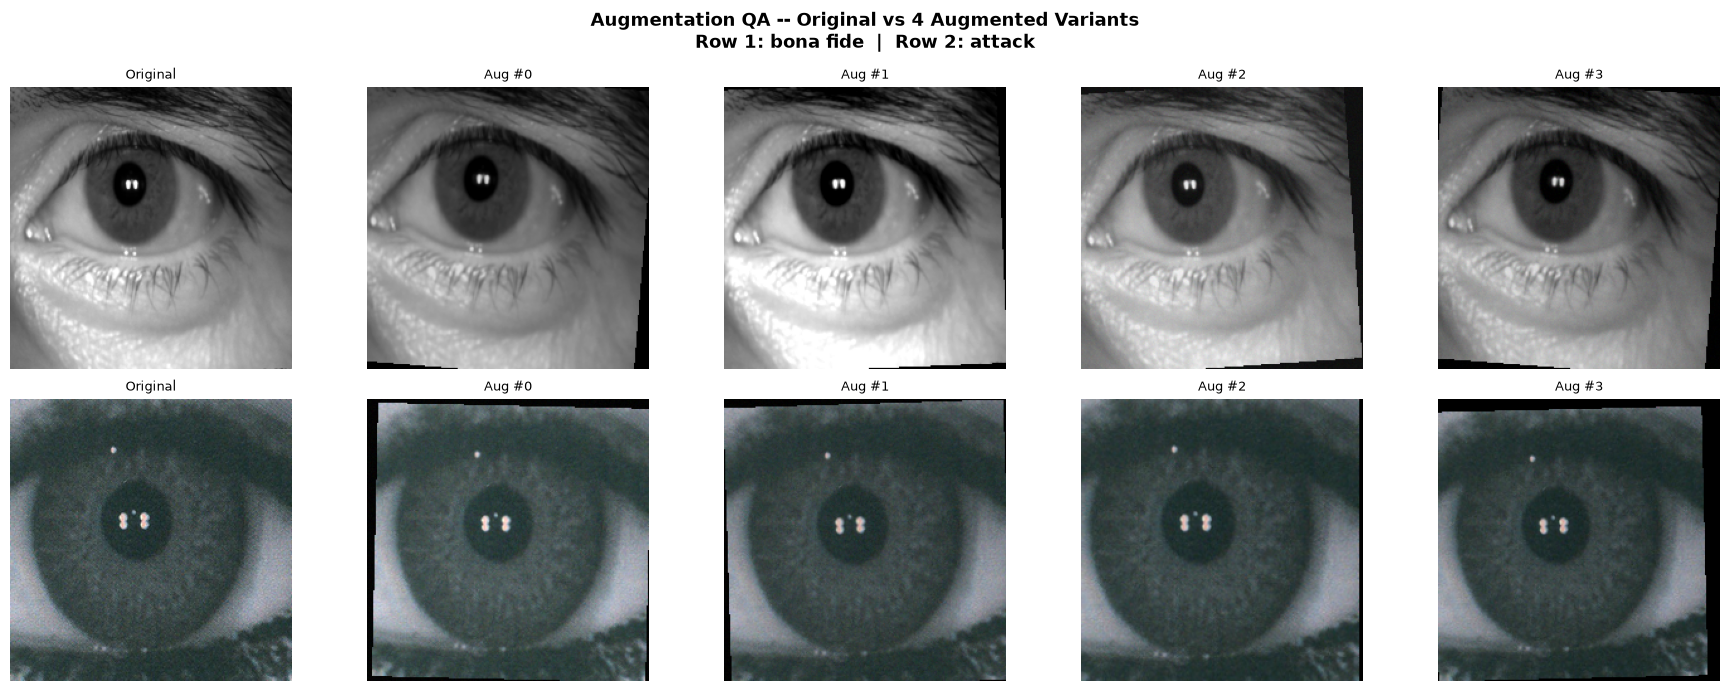

Saved -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\figures\augmentation_qa_grid.png


In [19]:
# CELL 25

# -----------------------------------------------------------------------
# Visual QA: original vs augmented, one bona_fide + one attack example.
# -----------------------------------------------------------------------
def denorm_for_display(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    img = tensor * std + mean
    return torch.clamp(img, 0, 1).permute(1,2,0).numpy()

if len(train_df):
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), facecolor='white')
    fig.suptitle('Augmentation QA -- Original vs 4 Augmented Variants\n'
                 'Row 1: bona fide  |  Row 2: attack', fontsize=13, fontweight='bold')

    for row_idx, label_val in enumerate([0, 1]):
        sub = train_df[train_df['label'] == label_val]
        if len(sub) == 0:
            continue
        sample_row = sub.iloc[0]
        try:
            orig_img = Image.open(sample_row['path']).convert('RGB')
        except Exception:
            continue
        orig_resized = orig_img.resize((IMG_SIZE, IMG_SIZE))
        axes[row_idx][0].imshow(orig_resized)
        axes[row_idx][0].set_title('Original', fontsize=9)
        axes[row_idx][0].axis('off')

        for k in range(4):
            aug_id = f'{sample_row["source_image_id"]}_qa_{k}'
            aug_tensor = deterministic_augment(orig_img, aug_id)
            axes[row_idx][k+1].imshow(denorm_for_display(aug_tensor))
            axes[row_idx][k+1].set_title(f'Aug #{k}', fontsize=9)
            axes[row_idx][k+1].axis('off')

    plt.tight_layout()
    save_p = OUT_DIRS['figures'] / 'augmentation_qa_grid.png'
    plt.savefig(save_p, dpi=130, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved -> {save_p}')
else:
    print('No train data -- augmentation QA skipped.')


In [20]:
def detect_and_crop_iris_v2(gray_arr, target_size=224):
    """
    More robust iris localization: instead of fragile Hough circles
    (which fail on noisy print-scan halftone patterns), find the
    DARKEST compact region (pupil is always the darkest area in any
    iris image regardless of capture method) and crop around it.
    """
    h, w = gray_arr.shape
    blurred = cv2.GaussianBlur(gray_arr, (15, 15), 3)

    # Threshold to find dark regions (pupil is darkest area)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find contours, pick the most CIRCULAR one near reasonable size
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    best_circle = None
    best_score = -1
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 100 or area > (h*w*0.3):
            continue
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        circularity = 4 * np.pi * area / (perimeter ** 2)
        if circularity > best_score:
            best_score = circularity
            (cx, cy), r = cv2.minEnclosingCircle(cnt)
            best_circle = (int(cx), int(cy), int(r))

    if best_circle is not None and best_score > 0.3:
        cx, cy, r = best_circle
    else:
        # Robust fallback: use overall image intensity centroid instead
        # of raw center -- weighted toward darker pixels (likely pupil area)
        inv = 255 - blurred
        ys, xs = np.indices((h, w))
        total_w = inv.sum() + 1e-6
        cx = int((xs * inv).sum() / total_w)
        cy = int((ys * inv).sum() / total_w)
        r = min(h, w) // 6

    crop_r = int(max(r * 3.0, min(h, w) * 0.15))
    x1, x2 = max(0, cx - crop_r), min(w, cx + crop_r)
    y1, y2 = max(0, cy - crop_r), min(h, cy + crop_r)
    cropped = gray_arr[y1:y2, x1:x2]
    if cropped.size == 0:
        cropped = gray_arr

    resized = cv2.resize(cropped, (target_size, target_size))
    return resized


def unify_preprocessing_v5(pil_img, center_crop_ratio=0.75):
    """
    Simpler, more reliable than automated iris detection: just take a
    fixed-ratio center crop (removes outer border/background variance)
    then resize. This avoids the false-positive circle/contour
    detection seen in v4 while still reducing zoom-level variance.
    """
    img = pil_img.convert('L')
    import io
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=90)
    buf.seek(0)
    arr = np.array(Image.open(buf).convert('L'))

    h, w = arr.shape
    crop_h, crop_w = int(h * center_crop_ratio), int(w * center_crop_ratio)
    y1 = (h - crop_h) // 2
    x1 = (w - crop_w) // 2
    cropped = arr[y1:y1+crop_h, x1:x1+crop_w]

    resized = cv2.resize(cropped, (224, 224))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    result = clahe.apply(resized)

    img_out = Image.fromarray(result).convert('RGB')
    return img_out

In [21]:
# CELL 26
# -----------------------------------------------------------------------
# PyTorch Dataset. For train split, expands each class to the target
# count computed in Section 6 using repeated (path, augmentation_id)
# pairs -- provenance preserved via augmentation_id string.
# -----------------------------------------------------------------------
class IrisPADDataset(Dataset):
    def __init__(self, df, mode='eval', expand_counts=None):
        '''
        mode: 'train' (apply deterministic augmentation, expanded) or
              'eval' (no augmentation, exactly one row per image)
        expand_counts: dict {0: n_bona_fide_target, 1: n_attack_target}, only
                        used when mode == 'train'
        '''
        self.mode = mode
        self.base_df = df.reset_index(drop=True)
        if mode == 'train' and expand_counts is not None:
            rows = []
            for label_val, target_n in expand_counts.items():
                sub = self.base_df[self.base_df['label'] == label_val]
                if len(sub) == 0:
                    continue
                n_repeats = max(1, int(np.ceil(target_n / len(sub))))
                for rep in range(n_repeats):
                    tmp = sub.copy()
                    tmp['augmentation_id'] = tmp['source_image_id'] + f'_rep{rep}'
                    rows.append(tmp)
                combined = pd.concat(rows, ignore_index=True)
            self.index_df = pd.concat(rows, ignore_index=True) if rows else self.base_df.copy()
            trimmed = []
            for label_val, target_n in expand_counts.items():
                sub = self.index_df[self.index_df['label'] == label_val].iloc[:target_n]
                trimmed.append(sub)
            self.index_df = pd.concat(trimmed, ignore_index=True) if trimmed else self.index_df
        else:
            self.index_df = self.base_df.copy()
            self.index_df['augmentation_id'] = self.index_df['source_image_id'] + '_orig'

    def __len__(self):
        return len(self.index_df)

    def __getitem__(self, idx):
        row = self.index_df.iloc[idx]
        try:
            img = Image.open(row['path'])
            img = unify_preprocessing_v5(img)   # <-- UPDATED: v4 se v5 pe change
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(0,0,0))

        if self.mode == 'train':
            tensor = deterministic_augment(img, row['augmentation_id'])
        else:
            tensor = eval_transform(img)

        return {
            'image'     : tensor,
            'label'     : int(row['label']),
            'subject_id': str(row['subject_id']),
            'sensor'    : str(row['sensor']),
            'path'      : str(row['path']),
        }


print('IrisPADDataset defined (mode=train applies expansion + augmentation; '
      'mode=eval is deterministic, one row per image).')

IrisPADDataset defined (mode=train applies expansion + augmentation; mode=eval is deterministic, one row per image).


In [22]:
# CELL 27
# -----------------------------------------------------------------------
# Build DataLoaders. Custom collate handles the metadata dict cleanly.
# -----------------------------------------------------------------------
def collate_fn(batch):
    images = torch.stack([b['image'] for b in batch])
    labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)
    subject_ids = [b['subject_id'] for b in batch]
    sensors     = [b['sensor'] for b in batch]
    paths       = [b['path'] for b in batch]
    return images, labels, subject_ids, sensors, paths

if len(train_df):
    expand_counts = {0: expanded_n_bf, 1: expanded_n_at}
    train_ds = IrisPADDataset(train_df, mode='train', expand_counts=expand_counts)
    val_ds   = IrisPADDataset(val_df,   mode='eval')
    test_ds  = IrisPADDataset(test_df,  mode='eval')

    BATCH_SIZE = CONFIG['batch_size']   # <-- YEH LINE MISSING THI

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=torch.cuda.is_available(),
                              collate_fn=collate_fn, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=torch.cuda.is_available(),
                              collate_fn=collate_fn)
    test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=torch.cuda.is_available(),
                              collate_fn=collate_fn)

    print(f'Train dataset (expanded): {len(train_ds)} samples/epoch')
    print(f'Val dataset              : {len(val_ds)} samples')
    print(f'Test dataset             : {len(test_ds)} samples')
    print(f'Batches per epoch (train): {len(train_loader)}')
else:
    train_loader = val_loader = test_loader = None
    print('No split available -- DataLoaders not built.')

Train dataset (expanded): 22448 samples/epoch
Val dataset              : 1285 samples
Test dataset             : 1267 samples
Batches per epoch (train): 701


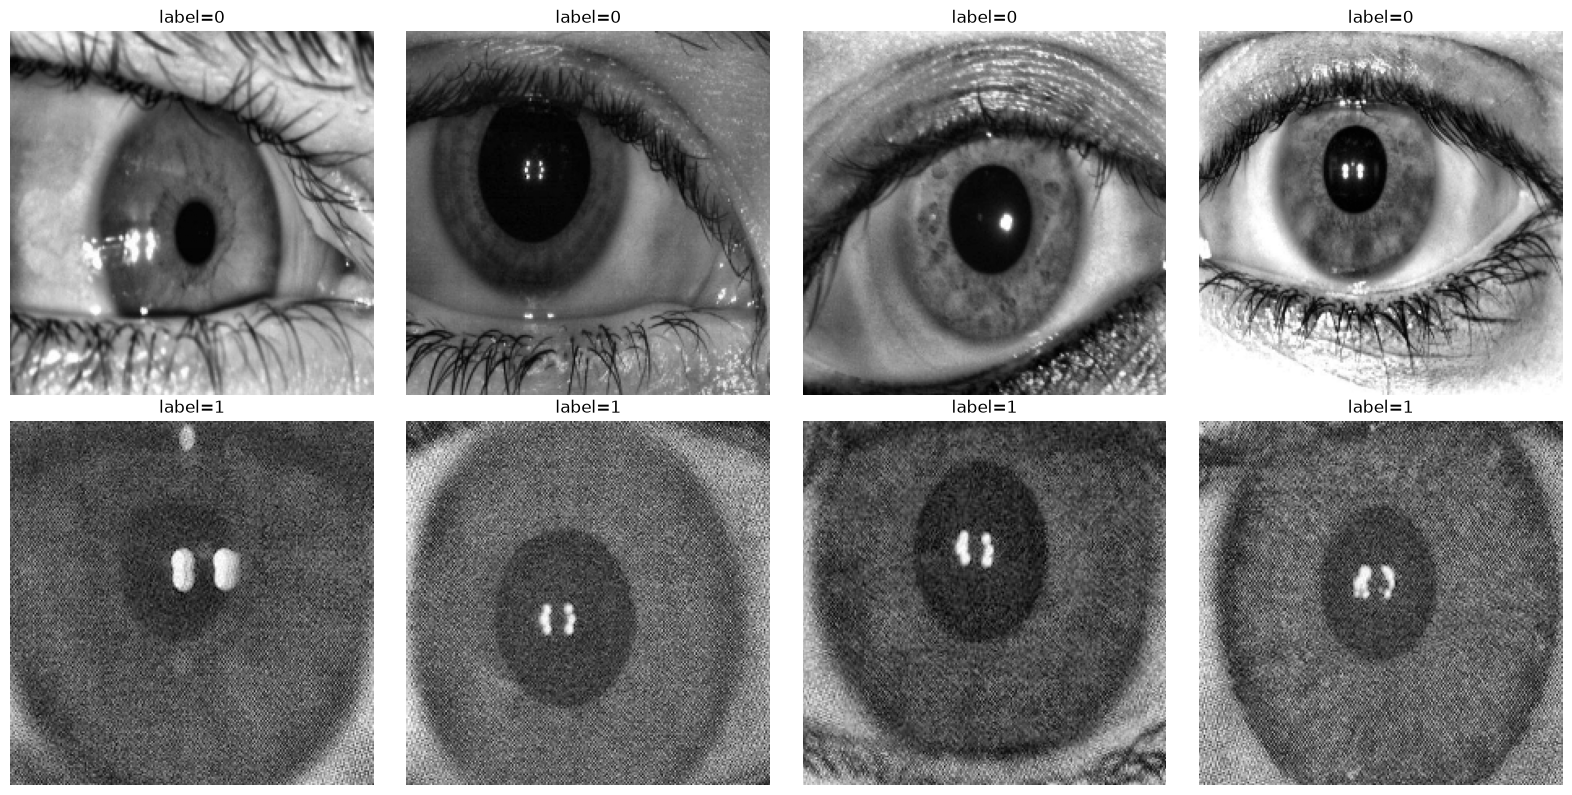

In [23]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
samples = pd.concat([
    train_df[train_df.label==0].sample(4, random_state=1),
    train_df[train_df.label==1].sample(4, random_state=1)
])
for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img = unify_preprocessing_v5(Image.open(row['path']))
    ax.imshow(np.array(img.convert('L')), cmap='gray')
    ax.set_title(f"label={row['label']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [24]:
train_subjects = set(train_df['subject_id'])
val_subjects = set(val_df['subject_id'])
overlap = train_subjects & val_subjects
print(f"Subject overlap between train and val: {len(overlap)}")

Subject overlap between train and val: 0


<!-- CELL 28 (Markdown) -->
## Section 7: PAD Metrics (with unit tests)

`label=0` bona fide, `label=1` attack. All continuous-score metrics operate on
`p_attack`. APCER/BPCER require a fixed decision threshold; EER is threshold-free
(computed by sweeping continuous scores).


In [25]:
# CELL 29

# -----------------------------------------------------------------------
# PAD metric functions with explicit unit tests to catch orientation bugs.
# -----------------------------------------------------------------------
def compute_apcer_bpcer_acer(y_true, y_pred):
    '''
    APCER: fraction of ATTACK (label=1) samples predicted as bona fide (pred=0).
    BPCER: fraction of BONA FIDE (label=0) samples predicted as attack (pred=1).
    ACER : mean(APCER, BPCER).
    '''
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    attack_mask = y_true == 1
    bf_mask     = y_true == 0
    apcer = float(np.mean(y_pred[attack_mask] == 0)) if attack_mask.sum() else 0.0
    bpcer = float(np.mean(y_pred[bf_mask] == 1)) if bf_mask.sum() else 0.0
    acer  = (apcer + bpcer) / 2.0
    return apcer, bpcer, acer


def compute_eer(y_true, p_attack):
    '''
    EER via continuous scores. FAR(t) = P(p_attack >= t | label=0)  (bona fide wrongly accepted as attack... )
    We define, consistent with APCER/BPCER convention:
      FRR(t) = APCER(t) = P(pred=0 | label=1) at threshold t  (attack accepted as bona fide)
      FAR(t) = BPCER(t) = P(pred=1 | label=0) at threshold t  (bona fide rejected as attack)
    EER = point where FRR(t) approx= FAR(t).
    '''
    y_true = np.asarray(y_true); p_attack = np.asarray(p_attack)
    thresholds = np.linspace(0.0, 1.0, 1000)
    frr, far = [], []
    for t in thresholds:
        pred = (p_attack >= t).astype(int)
        apcer, bpcer, _ = compute_apcer_bpcer_acer(y_true, pred)
        frr.append(apcer); far.append(bpcer)
    frr = np.array(frr); far = np.array(far)
    diff = np.abs(frr - far)
    idx = int(np.argmin(diff))
    eer = float((frr[idx] + far[idx]) / 2.0)
    eer_threshold = float(thresholds[idx])
    return eer, eer_threshold, thresholds, frr, far


def full_metric_suite(y_true, y_pred, p_attack):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); p_attack = np.asarray(p_attack)
    apcer, bpcer, acer = compute_apcer_bpcer_acer(y_true, y_pred)
    eer, eer_th, *_ = compute_eer(y_true, p_attack)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    try:
        auroc = roc_auc_score(y_true, p_attack)
    except Exception:
        auroc = float('nan')
    try:
        auprc = average_precision_score(y_true, p_attack)
    except Exception:
        auprc = float('nan')
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        'accuracy'          : accuracy_score(y_true, y_pred),
        'balanced_accuracy' : balanced_accuracy_score(y_true, y_pred),
        'precision'         : precision_score(y_true, y_pred, zero_division=0),
        'recall'            : recall_score(y_true, y_pred, zero_division=0),
        'specificity'       : specificity,
        'f1'                : f1_score(y_true, y_pred, zero_division=0),
        'auroc'             : auroc,
        'auprc'             : auprc,
        'apcer'             : apcer,
        'bpcer'             : bpcer,
        'acer'              : acer,
        'eer'               : eer,
        'eer_threshold'     : eer_th,
        'confusion_matrix'  : cm.tolist(),
    }


def _unit_test_metrics():
    y_true = np.array([0,0,0,0,1,1,1,1])
    y_pred_perfect = np.array([0,0,0,0,1,1,1,1])
    a,b,c = compute_apcer_bpcer_acer(y_true, y_pred_perfect)
    assert a == 0.0 and b == 0.0 and c == 0.0, 'Perfect prediction should give zero error'

    y_pred_all_attack = np.array([1,1,1,1,1,1,1,1])
    a,b,c = compute_apcer_bpcer_acer(y_true, y_pred_all_attack)
    assert a == 0.0 and b == 1.0, 'All-attack prediction: APCER=0 (all attacks correctly flagged), BPCER=1 (all bona fide wrongly flagged)'

    y_pred_all_bf = np.array([0,0,0,0,0,0,0,0])
    a,b,c = compute_apcer_bpcer_acer(y_true, y_pred_all_bf)
    assert a == 1.0 and b == 0.0, 'All-bona-fide prediction: APCER=1, BPCER=0'
    print('Unit tests passed: compute_apcer_bpcer_acer orientation is correct.')

_unit_test_metrics()
print('Metric suite ready: full_metric_suite(), compute_eer()')


Unit tests passed: compute_apcer_bpcer_acer orientation is correct.
Metric suite ready: full_metric_suite(), compute_eer()


<!-- CELL 30 (Markdown) -->
## Section 8: Five CNN + Attention Gate Architectures


In [26]:
# CELL 31

# -----------------------------------------------------------------------
# Attention modules: real spatial + channel gating, not a cosmetic scalar.
# -----------------------------------------------------------------------
class ChannelAttention(nn.Module):
    '''Squeeze-and-excitation style channel gate.'''
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, max(channels // reduction, 8)), nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 8), channels), nn.Sigmoid()
        )
    def forward(self, x):
        w = self.fc(self.pool(x)).view(x.size(0), x.size(1), 1, 1)
        return x * w, w


class SpatialAttention(nn.Module):
    '''CBAM-style spatial gate: avg+max pooled across channel dim -> conv -> sigmoid mask.'''
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True).values
        mask = self.sig(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * mask, mask


class ChannelSpatialAttentionGate(nn.Module):
    '''Sequential channel-then-spatial gate (CBAM-style), used by all 5 backbones
    to keep the attention mechanism architecturally consistent for comparison.'''
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)
    def forward(self, x):
        x, ch_w = self.channel_att(x)
        x, sp_w = self.spatial_att(x)
        return x, {'channel_weight': ch_w, 'spatial_mask': sp_w}


print('Attention modules defined: ChannelAttention, SpatialAttention, '
      'ChannelSpatialAttentionGate (used by all 5 architectures).')


Attention modules defined: ChannelAttention, SpatialAttention, ChannelSpatialAttentionGate (used by all 5 architectures).


In [27]:
# CELL 32

# -----------------------------------------------------------------------
# Model factory for the five CNN + Attention Gate architectures.
# Each model exposes: forward(x) -> (logits, attention_info_dict)
# -----------------------------------------------------------------------
class AttentionGatedCNN(nn.Module):
    def __init__(self, backbone_name, num_classes=2, dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == 'resnet18':
            net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            for name, p in net.named_parameters():
                if 'layer3' not in name and 'layer4' not in name:
                    p.requires_grad = False
            self.stem = nn.Sequential(*list(net.children())[:-2])
            self.feat_channels = 512

        elif backbone_name == 'densenet121':
            net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
            for name, p in net.named_parameters():
                if 'denseblock4' not in name and 'norm5' not in name:
                    p.requires_grad = False
            self.stem = net.features
            self.feat_channels = 1024

        elif backbone_name == 'vgg16':
            net = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            n_layers = len(net.features)
            for i, layer in enumerate(net.features):
                if i < n_layers - 6:
                    for p in layer.parameters():
                        p.requires_grad = False
            self.stem = net.features
            self.feat_channels = 512

        elif backbone_name == 'mobilenetv2':
            net = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            for name, p in net.named_parameters():
                if 'features.17' not in name and 'features.18' not in name:
                    p.requires_grad = False
            self.stem = net.features
            self.feat_channels = 1280

        elif backbone_name == 'densenet121_apbs_inspired':
            net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
            for name, p in net.named_parameters():
                if 'denseblock4' not in name and 'norm5' not in name:
                    p.requires_grad = False
            self.stem = net.features
            self.feat_channels = 1024
            # A-PBS-INSPIRED addition: auxiliary pixel-wise supervision head
            # operating on the pre-pool feature map, trained jointly with the
            # global classifier. This is adapted, not a literal reproduction.
            self.pixel_head = nn.Conv2d(self.feat_channels, 1, kernel_size=1)
        else:
            raise ValueError(f'Unknown backbone: {backbone_name}')

        self.attention = ChannelSpatialAttentionGate(self.feat_channels)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.feat_channels, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.75),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        feat = self.stem(x)
        feat, attn_info = self.attention(feat)
        pooled = self.global_pool(feat).flatten(1)
        logits = self.classifier(pooled)

        extra = {}
        if self.backbone_name == 'densenet121_apbs_inspired':
            extra['pixel_map'] = self.pixel_head(feat)
        attn_info.update(extra)
        return logits, attn_info


BACKBONE_NAMES = ['resnet18', 'densenet121', 'vgg16', 'mobilenetv2', 'densenet121_apbs_inspired']
BACKBONE_DISPLAY_NAMES = {
    'resnet18'                 : 'ResNet18 + Attention Gate',
    'densenet121'               : 'DenseNet121 + Attention Gate',
    'vgg16'                    : 'VGG16 + Attention Gate',
    'mobilenetv2'              : 'MobileNetV2 + Attention Gate',
    'densenet121_apbs_inspired': 'DenseNet121 + A-PBS-inspired Attention',
}

print('Model factory defined. Sanity-checking forward pass + parameter counts:')
for name in BACKBONE_NAMES:
    m = AttentionGatedCNN(name)
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    with torch.no_grad():
        out, attn_info = m(dummy)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f'  {BACKBONE_DISPLAY_NAMES[name]:42s}: logits {tuple(out.shape)} | '
          f'trainable {trainable:>10,} / {total:>10,}')
    del m


Model factory defined. Sanity-checking forward pass + parameter counts:
  ResNet18 + Attention Gate                 : logits (2, 2) | trainable 10,658,692 / 11,341,764
  DenseNet121 + Attention Gate              : logits (2, 2) | trainable  2,555,300 /  7,349,028
  VGG16 + Attention Gate                    : logits (2, 2) | trainable  4,884,868 / 14,879,940
  MobileNetV2 + Attention Gate              : logits (2, 2) | trainable  1,420,788 /  2,758,580
  DenseNet121 + A-PBS-inspired Attention    : logits (2, 2) | trainable  2,556,325 /  7,350,053


<!-- CELL 33 (Markdown) -->
## Section 9: Training Utilities

AdamW + optional AMP + gradient clipping + cosine schedule. Checkpoint selection
is based on **minimum validation ACER**, not maximum validation accuracy, per the
PAD-oriented model-selection requirement.


In [28]:
# CELL 34

# -----------------------------------------------------------------------
# Training and validation loop utilities shared by all five models.
# -----------------------------------------------------------------------
scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def compute_class_weights(train_df):
    counts = train_df['label'].value_counts()
    n_total = len(train_df)
    w0 = n_total / (2.0 * max(counts.get(0, 1), 1))
    w1 = n_total / (2.0 * max(counts.get(1, 1), 1))
    return torch.tensor([w0, w1], dtype=torch.float)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_true, all_pred, all_prob = [], [], []
    for images, labels, *_ in tqdm(loader, desc='  train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits, _ = model(images)
            loss = criterion(logits, labels)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()

        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        preds = logits.argmax(1).detach().cpu().numpy()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
        all_true.extend(labels.cpu().numpy()); all_pred.extend(preds); all_prob.extend(probs)

    metrics = full_metric_suite(all_true, all_pred, all_prob)
    metrics['loss'] = total_loss / max(total, 1)
    metrics['accuracy_running'] = correct / max(total, 1)
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0
    all_true, all_pred, all_prob = [], [], []
    all_subjects, all_sensors, all_paths = [], [], []
    for images, labels, subjects, sensors, paths in tqdm(loader, desc='  eval', leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits, _ = model(images)
            loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)
        all_true.extend(labels.cpu().numpy()); all_pred.extend(preds); all_prob.extend(probs)
        all_subjects.extend(subjects); all_sensors.extend(sensors); all_paths.extend(paths)

    metrics = full_metric_suite(all_true, all_pred, all_prob)
    metrics['loss'] = total_loss / max(total, 1)
    raw = {'y_true': np.array(all_true), 'y_pred': np.array(all_pred),
           'p_attack': np.array(all_prob), 'subject_id': all_subjects,
           'sensor': all_sensors, 'path': all_paths}
    return metrics, raw


def train_model_full(backbone_name, train_loader, val_loader, config, class_weights, device):
    model = AttentionGatedCNN(backbone_name).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['max_epochs'], eta_min=1e-6)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
               'train_acer':[], 'val_acer':[], 'lr':[]}
    best_val_acer = float('inf')
    patience_counter = 0
    ckpt_path = OUT_DIRS['checkpoints'] / f'best_{backbone_name}_attention.pth'
    best_epoch = 0

    t0 = time.time()
    for epoch in range(1, config['max_epochs'] + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_m, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_m['loss']); history['val_loss'].append(val_m['loss'])
        history['train_acc'].append(train_m['accuracy']); history['val_acc'].append(val_m['accuracy'])
        history['train_acer'].append(train_m['acer']); history['val_acer'].append(val_m['acer'])
        history['lr'].append(optimizer.param_groups[0]['lr'])

        marker = ''
        if val_m['acer'] < best_val_acer:
            best_val_acer = val_m['acer']
            patience_counter = 0
            best_epoch = epoch
            torch.save(model.state_dict(), ckpt_path)
            marker = ' <- best (val ACER)'
        else:
            patience_counter += 1

        print(f'  [{backbone_name}] Ep{epoch:>3d} | TrLoss:{train_m["loss"]:.4f} '
              f'TrACER:{train_m["acer"]*100:.2f}% | ValLoss:{val_m["loss"]:.4f} '
              f'ValACER:{val_m["acer"]*100:.2f}%{marker}')

        if patience_counter >= config['early_stop_patience']:
            print(f'  [{backbone_name}] Early stop at epoch {epoch} '
                  f'(best val ACER {best_val_acer*100:.2f}% at epoch {best_epoch})')
            break

    train_time = time.time() - t0
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))

    with open(OUT_DIRS['histories'] / f'{backbone_name}_history.json', 'w') as f:
        json.dump(history, f, indent=2)

    return model, history, {
        'best_epoch': best_epoch, 'stopping_epoch': epoch,
        'best_val_acer': best_val_acer, 'train_time_sec': train_time,
        'checkpoint_path': str(ckpt_path),
    }

print('Training utilities defined: train_one_epoch, evaluate, train_model_full.')
print('Checkpoint selection criterion: MINIMUM validation ACER (not accuracy).')


Training utilities defined: train_one_epoch, evaluate, train_model_full.
Checkpoint selection criterion: MINIMUM validation ACER (not accuracy).


In [29]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

def check_full_pixel_shortcut(df, n_samples=300):
    imgs = []
    labels = []
    sample_df = df.sample(min(n_samples, len(df)), random_state=42)
    for _, row in sample_df.iterrows():
        img = unify_preprocessing_v5(Image.open(row['path']))
        arr = np.array(img.convert('L').resize((64,64))).flatten()
        imgs.append(arr)
        labels.append(row['label'])
    X = np.array(imgs, dtype=np.float32)
    y = np.array(labels)
    X_pca = PCA(n_components=20, random_state=42).fit_transform(X)
    clf = LogisticRegression(max_iter=1000).fit(X_pca, y)
    return clf.score(X_pca, y)

print("check_full_pixel_shortcut() defined")

check_full_pixel_shortcut() defined


In [30]:
majority_baseline = train_df['label'].value_counts(normalize=True).max()
full_pixel_acc_v5 = check_full_pixel_shortcut(train_df)
print(f"Full-pixel (PCA-20) shortcut accuracy AFTER v5 fix: {full_pixel_acc_v5*100:.2f}%")
print(f"Majority baseline: {majority_baseline*100:.2f}%")

train_subjects = set(train_df['subject_id'])
val_subjects = set(val_df['subject_id'])
overlap = train_subjects & val_subjects
print(f"Subject overlap between train and val: {len(overlap)}")

Full-pixel (PCA-20) shortcut accuracy AFTER v5 fix: 94.67%
Majority baseline: 72.13%
Subject overlap between train and val: 0


In [31]:
# CELL 35

# -----------------------------------------------------------------------
# Train all five CNN + Attention Gate architectures sequentially.
# Each uses the identical train/val/test split, augmentation policy,
# seed, and optimization protocol for fairness.
# -----------------------------------------------------------------------
all_models = {}
all_histories = {}
all_train_info = {}

if train_loader is not None:
    class_weights = compute_class_weights(train_df)
    print(f'Class weights (bona_fide, attack): {class_weights.tolist()}')

    for backbone_name in BACKBONE_NAMES:
        print(f'\n{"#"*70}')
        print(f'#  TRAINING: {BACKBONE_DISPLAY_NAMES[backbone_name]}')
        print(f'{"#"*70}')
        model, history, train_info = train_model_full(
            backbone_name, train_loader, val_loader, CONFIG, class_weights, DEVICE
        )
        all_models[backbone_name] = model
        all_histories[backbone_name] = history
        all_train_info[backbone_name] = train_info

    with open(OUT_DIRS['histories'] / 'all_train_info.json', 'w') as f:
        json.dump(all_train_info, f, indent=2)

    print('\nAll 5 models trained. Summary:')
    for name, info in all_train_info.items():
        print(f'  {BACKBONE_DISPLAY_NAMES[name]:42s}: best_val_ACER={info["best_val_acer"]*100:.2f}%  '
              f'best_epoch={info["best_epoch"]}  train_time={info["train_time_sec"]:.0f}s')
else:
    print('No train_loader available -- training skipped. Fix dataset paths and re-run.')


Class weights (bona_fide, attack): [0.6931467652320862, 1.794352412223816]

######################################################################
#  TRAINING: ResNet18 + Attention Gate
######################################################################


  train:   0%|          | 0/701 [00:00<?, ?it/s]

  eval:   0%|          | 0/41 [00:00<?, ?it/s]

  [resnet18] Ep  1 | TrLoss:0.0186 TrACER:0.22% | ValLoss:0.0251 ValACER:0.65% <- best (val ACER)


  train:   0%|          | 0/701 [00:00<?, ?it/s]

...

  eval:   0%|          | 0/41 [00:00<?, ?it/s]

  [densenet121_apbs_inspired] Ep 29 | TrLoss:0.0000 TrACER:0.00% | ValLoss:0.0224 ValACER:0.65%


  train:   0%|          | 0/701 [00:00<?, ?it/s]

  eval:   0%|          | 0/41 [00:00<?, ?it/s]

  [densenet121_apbs_inspired] Ep 30 | TrLoss:0.0000 TrACER:0.00% | ValLoss:0.0284 ValACER:0.65%
  [densenet121_apbs_inspired] Early stop at epoch 30 (best val ACER 0.26% at epoch 5)

All 5 models trained. Summary:
  ResNet18 + Attention Gate                 : best_val_ACER=0.00%  best_epoch=5  train_time=46183s
  DenseNet121 + Attention Gate              : best_val_ACER=0.19%  best_epoch=11  train_time=44173s
  VGG16 + Attention Gate                    : best_val_ACER=0.06%  best_epoch=1  train_time=25286s
  MobileNetV2 + Attention Gate              : best_val_ACER=0.13%  best_epoch=18  train_time=24136s
  DenseNet121 + A-PBS-inspired Attention    : best_val_ACER=0.26%  best_epoch=5  train_time=19381s


In [32]:
# CELL 36

# -----------------------------------------------------------------------
# Final test-set evaluation for all five models. Saves per-model logits/
# probabilities/labels/subject IDs/sensor IDs/predictions/thresholds --
# the exact interface Notebooks B-E depend on.
# -----------------------------------------------------------------------
all_test_metrics = {}
all_test_raw = {}


if test_loader is not None and len(all_models):
    criterion_eval = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    for backbone_name, model in all_models.items():
        test_m, raw = evaluate(model, test_loader, criterion_eval, DEVICE)
        all_test_metrics[backbone_name] = test_m
        all_test_raw[backbone_name] = raw

        np.savez(
            OUT_DIRS['predictions'] / f'{backbone_name}_test_predictions.npz',
            y_true=raw['y_true'], y_pred=raw['y_pred'], p_attack=raw['p_attack'],
            subject_id=np.array(raw['subject_id']), sensor=np.array(raw['sensor']),
            path=np.array(raw['path']), threshold_used=np.array([0.5]),
            eer_threshold=np.array([test_m['eer_threshold']]),
        )
        print(f'{BACKBONE_DISPLAY_NAMES[backbone_name]:42s}: '
              f'Acc={test_m["accuracy"]*100:.2f}%  APCER={test_m["apcer"]*100:.2f}%  '
              f'BPCER={test_m["bpcer"]*100:.2f}%  ACER={test_m["acer"]*100:.2f}%  '
              f'EER={test_m["eer"]*100:.2f}%  AUROC={test_m["auroc"]:.4f}')

    with open(OUT_DIRS['metrics'] / 'all_test_metrics.json', 'w') as f:
        json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'confusion_matrix'}
                   for k, v in all_test_metrics.items()}, f, indent=2)
    print('\nSaved per-model .npz prediction files -> outputs/predictions/')
    print('Saved -> outputs/metrics/all_test_metrics.json')
else:
    print('No trained models / test loader -- evaluation skipped.')


  eval:   0%|          | 0/40 [00:00<?, ?it/s]

ResNet18 + Attention Gate                 : Acc=100.00%  APCER=0.00%  BPCER=0.00%  ACER=0.00%  EER=0.00%  AUROC=1.0000


  eval:   0%|          | 0/40 [00:00<?, ?it/s]

DenseNet121 + Attention Gate              : Acc=100.00%  APCER=0.00%  BPCER=0.00%  ACER=0.00%  EER=0.00%  AUROC=1.0000


  eval:   0%|          | 0/40 [00:00<?, ?it/s]

VGG16 + Attention Gate                    : Acc=99.92%  APCER=0.00%  BPCER=0.11%  ACER=0.06%  EER=0.00%  AUROC=1.0000


  eval:   0%|          | 0/40 [00:00<?, ?it/s]

MobileNetV2 + Attention Gate              : Acc=100.00%  APCER=0.00%  BPCER=0.00%  ACER=0.00%  EER=0.00%  AUROC=1.0000


  eval:   0%|          | 0/40 [00:00<?, ?it/s]

DenseNet121 + A-PBS-inspired Attention    : Acc=100.00%  APCER=0.00%  BPCER=0.00%  ACER=0.00%  EER=0.00%  AUROC=1.0000

Saved per-model .npz prediction files -> outputs/predictions/
Saved -> outputs/metrics/all_test_metrics.json


In [33]:
# CELL 37

# -----------------------------------------------------------------------
# Master comparison table across all 5 models, including model
# complexity (params, size, inference latency).
# -----------------------------------------------------------------------
def measure_inference_latency(model, device, n_reps=30):
    model.eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        for _ in range(5):
            model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_reps):
            model(dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - t0
    return (elapsed / n_reps) * 1000.0  # ms

master_rows = []
if len(all_test_metrics):
    for backbone_name, model in all_models.items():
        m = all_test_metrics[backbone_name]
        info = all_train_info[backbone_name]
        n_params = sum(p.numel() for p in model.parameters())
        ckpt_size_mb = Path(info['checkpoint_path']).stat().st_size / (1024*1024) \
                        if Path(info['checkpoint_path']).exists() else float('nan')
        latency_ms = measure_inference_latency(model, DEVICE)

        master_rows.append({
            'Model': BACKBONE_DISPLAY_NAMES[backbone_name],
            'Backbone_key': backbone_name,
            'Accuracy_%': round(m['accuracy']*100, 2),
            'Balanced_Acc_%': round(m['balanced_accuracy']*100, 2),
            'Precision': round(m['precision'], 4),
            'Recall': round(m['recall'], 4),
            'Specificity': round(m['specificity'], 4),
            'F1': round(m['f1'], 4),
            'AUROC': round(m['auroc'], 4),
            'AUPRC': round(m['auprc'], 4),
            'APCER_%': round(m['apcer']*100, 2),
            'BPCER_%': round(m['bpcer']*100, 2),
            'ACER_%': round(m['acer']*100, 2),
            'EER_%': round(m['eer']*100, 2),
            'Params': n_params,
            'Size_MB': round(ckpt_size_mb, 2),
            'Latency_ms': round(latency_ms, 3),
            'Best_Epoch': info['best_epoch'],
            'Stopping_Epoch': info['stopping_epoch'],
            'Train_Time_sec': round(info['train_time_sec'], 1),
        })

    master_df = pd.DataFrame(master_rows)
    master_df.to_csv(OUT_DIRS['metrics'] / 'master_comparison_table.csv', index=False)
    print('='*100)
    print('MASTER COMPARISON -- 5 CNN + Attention Gate baselines')
    print('='*100)
    print(master_df.to_string(index=False))
    print('\nSaved -> outputs/metrics/master_comparison_table.csv')
else:
    master_df = pd.DataFrame()
    print('No metrics available -- master table skipped.')


MASTER COMPARISON -- 5 CNN + Attention Gate baselines
                                 Model              Backbone_key  Accuracy_%  Balanced_Acc_%  Precision  Recall  Specificity     F1  AUROC  AUPRC  APCER_%  BPCER_%  ACER_%  EER_%   Params  Size_MB  Latency_ms  Best_Epoch  Stopping_Epoch  Train_Time_sec
             ResNet18 + Attention Gate                  resnet18      100.00          100.00     1.0000     1.0       1.0000 1.0000    1.0    1.0      0.0     0.00    0.00    0.0 11341764    43.35      28.579           5              30         46183.2
          DenseNet121 + Attention Gate               densenet121      100.00          100.00     1.0000     1.0       1.0000 1.0000    1.0    1.0      0.0     0.00    0.00    0.0  7349028    28.62      97.216          11              36         44172.7
                VGG16 + Attention Gate                     vgg16       99.92           99.94     0.9973     1.0       0.9989 0.9986    1.0    1.0      0.0     0.11    0.06    0.0 14879940

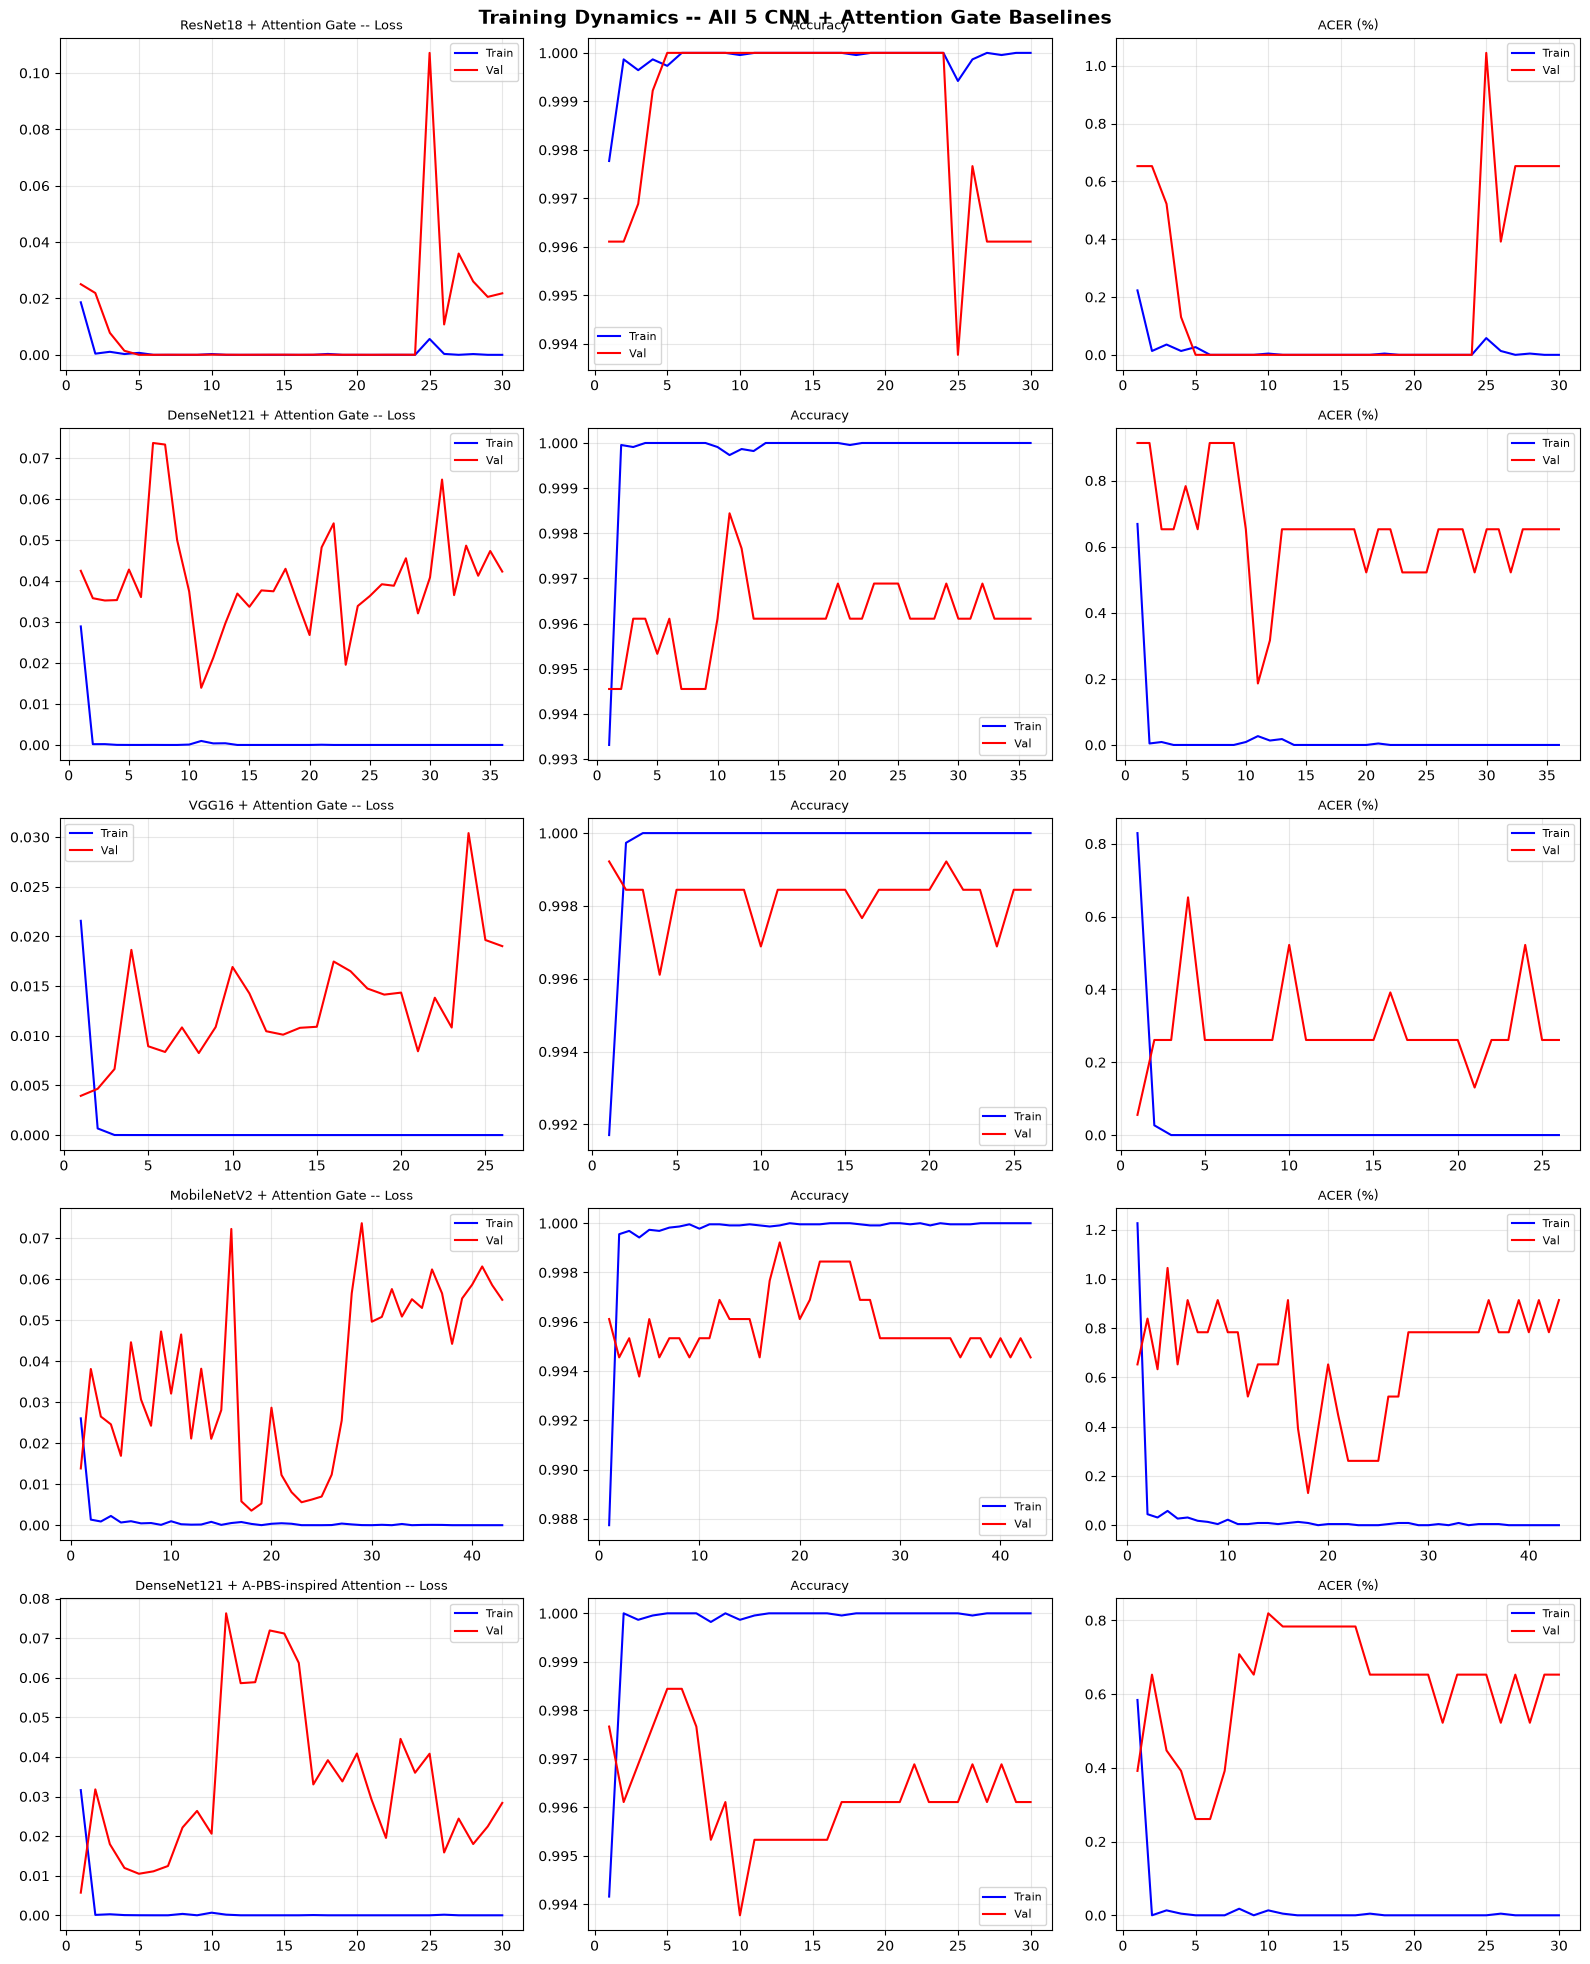

Saved -> outputs/figures/learning_curves_all_models.{png,pdf}


In [34]:
# CELL 38

# -----------------------------------------------------------------------
# Figure set 1: loss / accuracy learning curves per model + combined.
# -----------------------------------------------------------------------
if len(all_histories):
    fig, axes = plt.subplots(len(BACKBONE_NAMES), 3, figsize=(16, 4*len(BACKBONE_NAMES)), facecolor='white')
    fig.suptitle('Training Dynamics -- All 5 CNN + Attention Gate Baselines', fontsize=14, fontweight='bold')

    for row, name in enumerate(BACKBONE_NAMES):
        h = all_histories[name]
        ep = range(1, len(h['train_loss'])+1)
        axes[row][0].plot(ep, h['train_loss'], 'b-', label='Train'); axes[row][0].plot(ep, h['val_loss'], 'r-', label='Val')
        axes[row][0].set_title(f'{BACKBONE_DISPLAY_NAMES[name]} -- Loss', fontsize=9); axes[row][0].legend(fontsize=8); axes[row][0].grid(alpha=0.3)

        axes[row][1].plot(ep, h['train_acc'], 'b-', label='Train'); axes[row][1].plot(ep, h['val_acc'], 'r-', label='Val')
        axes[row][1].set_title('Accuracy', fontsize=9); axes[row][1].legend(fontsize=8); axes[row][1].grid(alpha=0.3)

        axes[row][2].plot(ep, [x*100 for x in h['train_acer']], 'b-', label='Train'); axes[row][2].plot(ep, [x*100 for x in h['val_acer']], 'r-', label='Val')
        axes[row][2].set_title('ACER (%)', fontsize=9); axes[row][2].legend(fontsize=8); axes[row][2].grid(alpha=0.3)

    plt.tight_layout()
    for ext in ['png', 'pdf']:
        plt.savefig(OUT_DIRS['figures'] / f'learning_curves_all_models.{ext}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved -> outputs/figures/learning_curves_all_models.{png,pdf}')
else:
    print('No histories available -- learning curve figure skipped.')


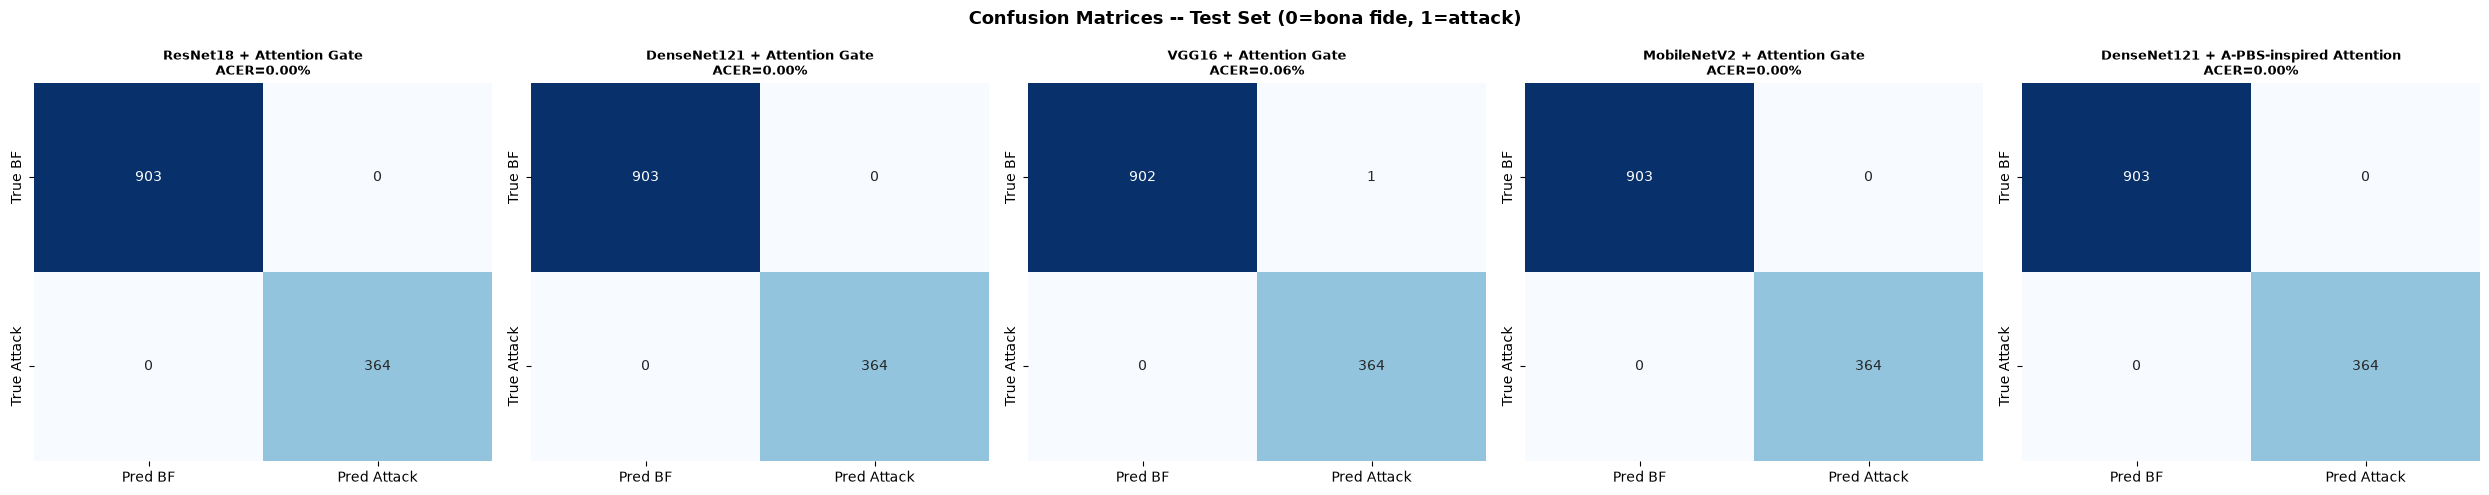

Saved -> outputs/figures/confusion_matrices_all_models.{png,pdf}


In [35]:
# CELL 39

# -----------------------------------------------------------------------
# Figure set 2: confusion matrices, all 5 models.
# -----------------------------------------------------------------------
if len(all_test_metrics):
    fig, axes = plt.subplots(1, len(BACKBONE_NAMES), figsize=(5*len(BACKBONE_NAMES), 5), facecolor='white')
    if len(BACKBONE_NAMES) == 1: axes = [axes]
    fig.suptitle('Confusion Matrices -- Test Set (0=bona fide, 1=attack)', fontsize=13, fontweight='bold')
    for ax, name in zip(axes, BACKBONE_NAMES):
        cm = np.array(all_test_metrics[name]['confusion_matrix'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Pred BF','Pred Attack'], yticklabels=['True BF','True Attack'],
                    ax=ax, cbar=False)
        ax.set_title(f'{BACKBONE_DISPLAY_NAMES[name]}\nACER={all_test_metrics[name]["acer"]*100:.2f}%',
                     fontsize=9, fontweight='bold')
    plt.tight_layout()
    for ext in ['png','pdf']:
        plt.savefig(OUT_DIRS['figures'] / f'confusion_matrices_all_models.{ext}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved -> outputs/figures/confusion_matrices_all_models.{png,pdf}')
else:
    print('No test metrics -- confusion matrix figure skipped.')


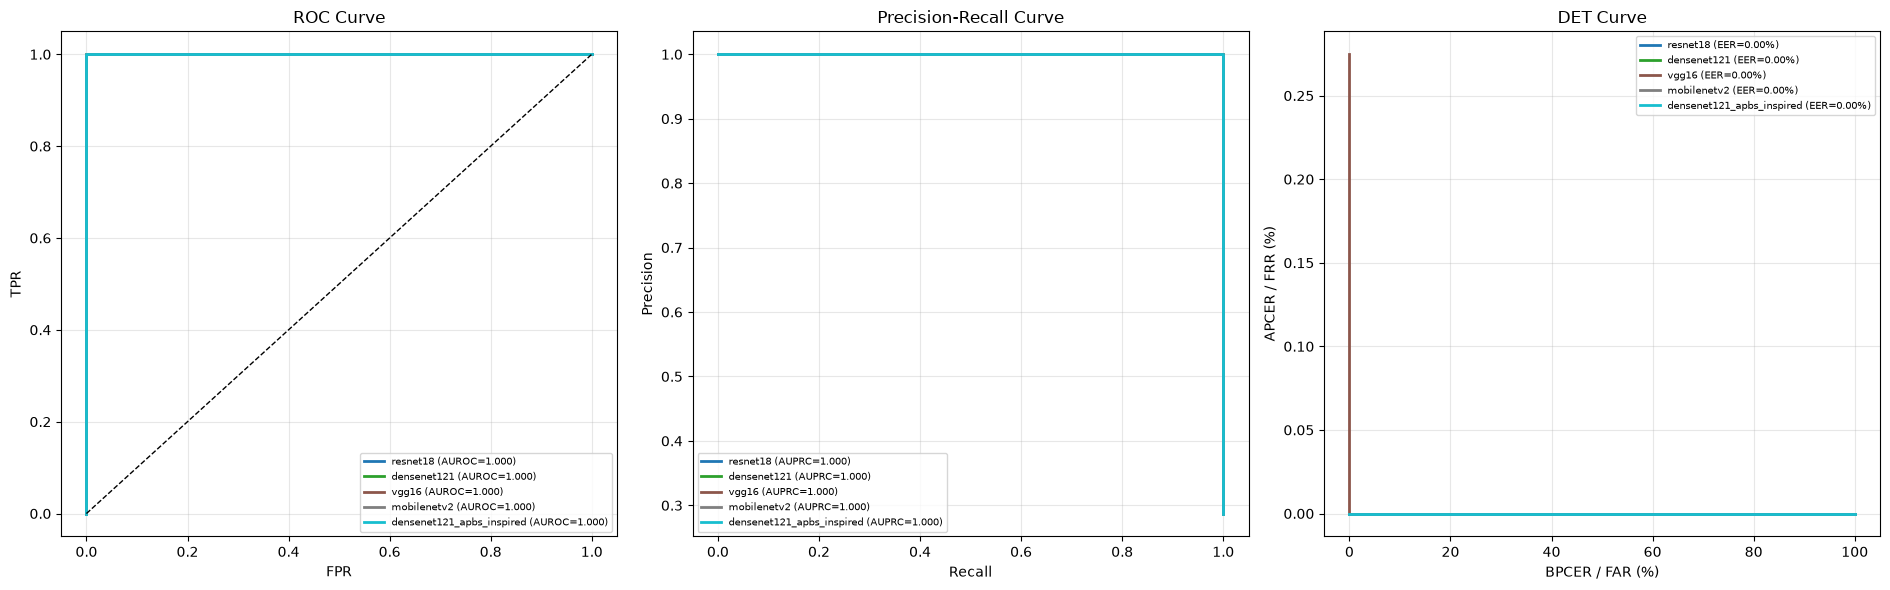

Saved -> outputs/figures/roc_pr_det_combined.{png,pdf}


In [36]:
# CELL 40

# -----------------------------------------------------------------------
# Figure set 3: ROC, Precision-Recall, and DET curves, all models overlaid.
# -----------------------------------------------------------------------
if len(all_test_raw):
    fig, axes = plt.subplots(1, 3, figsize=(19, 6), facecolor='white')
    colors = plt.cm.tab10(np.linspace(0, 1, len(BACKBONE_NAMES)))

    for name, color in zip(BACKBONE_NAMES, colors):
        raw = all_test_raw[name]
        fpr, tpr, _ = roc_curve(raw['y_true'], raw['p_attack'])
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUROC={all_test_metrics[name]["auroc"]:.3f})')

        prec, rec, _ = precision_recall_curve(raw['y_true'], raw['p_attack'])
        axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AUPRC={all_test_metrics[name]["auprc"]:.3f})')

        _, _, thresholds, frr, far = compute_eer(raw['y_true'], raw['p_attack'])
        axes[2].plot(far*100, frr*100, color=color, lw=2, label=f'{name} (EER={all_test_metrics[name]["eer"]*100:.2f}%)')

    axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

    axes[2].set(xlabel='BPCER / FAR (%)', ylabel='APCER / FRR (%)', title='DET Curve')
    axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    for ext in ['png','pdf']:
        plt.savefig(OUT_DIRS['figures'] / f'roc_pr_det_combined.{ext}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved -> outputs/figures/roc_pr_det_combined.{png,pdf}')
else:
    print('No test raw predictions -- ROC/PR/DET figure skipped.')


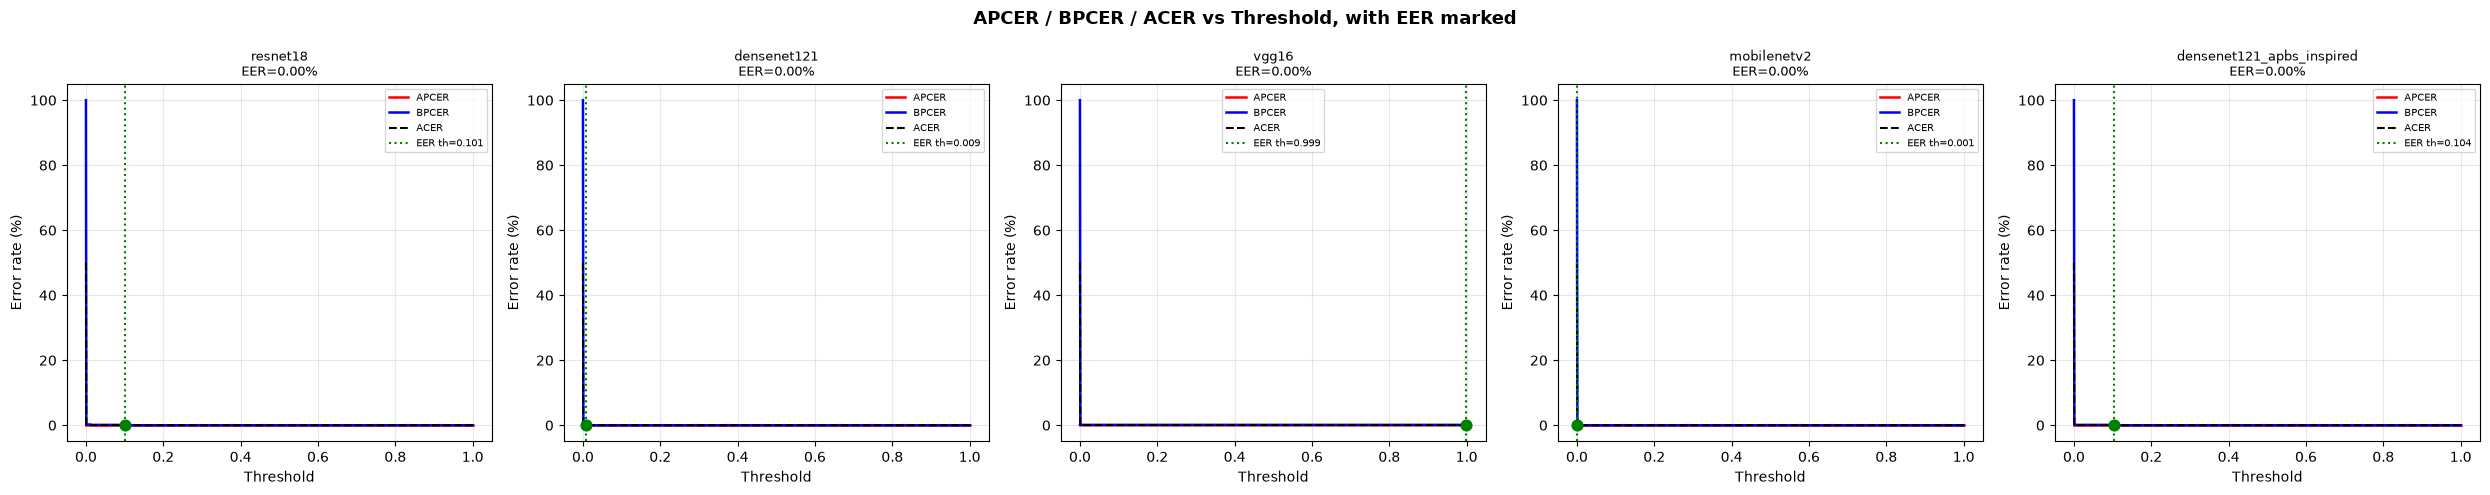

Saved -> outputs/figures/apcer_bpcer_acer_eer_sweep.{png,pdf}


In [37]:
# CELL 41

# -----------------------------------------------------------------------
# Figure set 4: APCER/BPCER/ACER sweep vs threshold + EER visualization,
# per model.
# -----------------------------------------------------------------------
if len(all_test_raw):
    fig, axes = plt.subplots(1, len(BACKBONE_NAMES), figsize=(5*len(BACKBONE_NAMES), 5), facecolor='white')
    if len(BACKBONE_NAMES) == 1: axes = [axes]
    fig.suptitle('APCER / BPCER / ACER vs Threshold, with EER marked', fontsize=13, fontweight='bold')

    for ax, name in zip(axes, BACKBONE_NAMES):
        raw = all_test_raw[name]
        eer, eer_th, thresholds, frr, far = compute_eer(raw['y_true'], raw['p_attack'])
        acer_curve = (frr + far) / 2.0

        ax.plot(thresholds, frr*100, 'r-', lw=1.8, label='APCER')
        ax.plot(thresholds, far*100, 'b-', lw=1.8, label='BPCER')
        ax.plot(thresholds, acer_curve*100, 'k--', lw=1.5, label='ACER')
        ax.axvline(eer_th, color='green', lw=1.5, linestyle=':', label=f'EER th={eer_th:.3f}')
        ax.scatter([eer_th], [eer*100], color='green', s=60, zorder=5)
        ax.set_title(f'{name}\nEER={eer*100:.2f}%', fontsize=9)
        ax.set_xlabel('Threshold'); ax.set_ylabel('Error rate (%)')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()
    for ext in ['png','pdf']:
        plt.savefig(OUT_DIRS['figures'] / f'apcer_bpcer_acer_eer_sweep.{ext}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved -> outputs/figures/apcer_bpcer_acer_eer_sweep.{png,pdf}')
else:
    print('No test raw predictions -- threshold sweep figure skipped.')


In [38]:
# CELL 42

# -----------------------------------------------------------------------
# Sensor-wise (Cogent vs Vista) analysis, where sensor metadata permits.
# IIITDNewNormal rows have sensor='NA' and are excluded from this
# specific breakdown (their bona fide samples still appear in the
# overall metrics above).
# -----------------------------------------------------------------------
sensor_rows = []
if len(all_test_raw):
    for name in BACKBONE_NAMES:
        raw = all_test_raw[name]
        df_raw = pd.DataFrame({
            'y_true': raw['y_true'], 'y_pred': raw['y_pred'],
            'p_attack': raw['p_attack'], 'sensor': raw['sensor'],
        })
        for sensor in ['Cogent', 'Vista']:
            sub = df_raw[df_raw['sensor'] == sensor]
            if len(sub) == 0:
                continue
            apcer, bpcer, acer = compute_apcer_bpcer_acer(sub['y_true'], sub['y_pred'])
            try:
                auroc = roc_auc_score(sub['y_true'], sub['p_attack']) if sub['y_true'].nunique() > 1 else float('nan')
            except Exception:
                auroc = float('nan')
            sensor_rows.append({
                'Model': name, 'Sensor': sensor, 'N': len(sub),
                'APCER_%': round(apcer*100, 2), 'BPCER_%': round(bpcer*100, 2),
                'ACER_%': round(acer*100, 2), 'AUROC': round(auroc, 4) if not np.isnan(auroc) else None,
            })

    sensor_df = pd.DataFrame(sensor_rows)
    if len(sensor_df):
        sensor_df.to_csv(OUT_DIRS['metrics'] / 'sensor_wise_metrics.csv', index=False)
        print('Sensor-wise (Cogent vs Vista) ACER breakdown:')
        print(sensor_df.to_string(index=False))
        print('\nSaved -> outputs/metrics/sensor_wise_metrics.csv')
    else:
        print('No Cogent/Vista sensor rows found in test predictions (attack samples may all '
              'have landed in train/val, or sensor metadata is missing) -- check split balance.')
else:
    print('No test predictions available -- sensor-wise analysis skipped.')


Sensor-wise (Cogent vs Vista) ACER breakdown:
                    Model Sensor   N  APCER_%  BPCER_%  ACER_% AUROC
                 resnet18 Cogent 176      0.0      0.0     0.0  None
                 resnet18  Vista 188      0.0      0.0     0.0  None
              densenet121 Cogent 176      0.0      0.0     0.0  None
              densenet121  Vista 188      0.0      0.0     0.0  None
                    vgg16 Cogent 176      0.0      0.0     0.0  None
                    vgg16  Vista 188      0.0      0.0     0.0  None
              mobilenetv2 Cogent 176      0.0      0.0     0.0  None
              mobilenetv2  Vista 188      0.0      0.0     0.0  None
densenet121_apbs_inspired Cogent 176      0.0      0.0     0.0  None
densenet121_apbs_inspired  Vista 188      0.0      0.0     0.0  None

Saved -> outputs/metrics/sensor_wise_metrics.csv


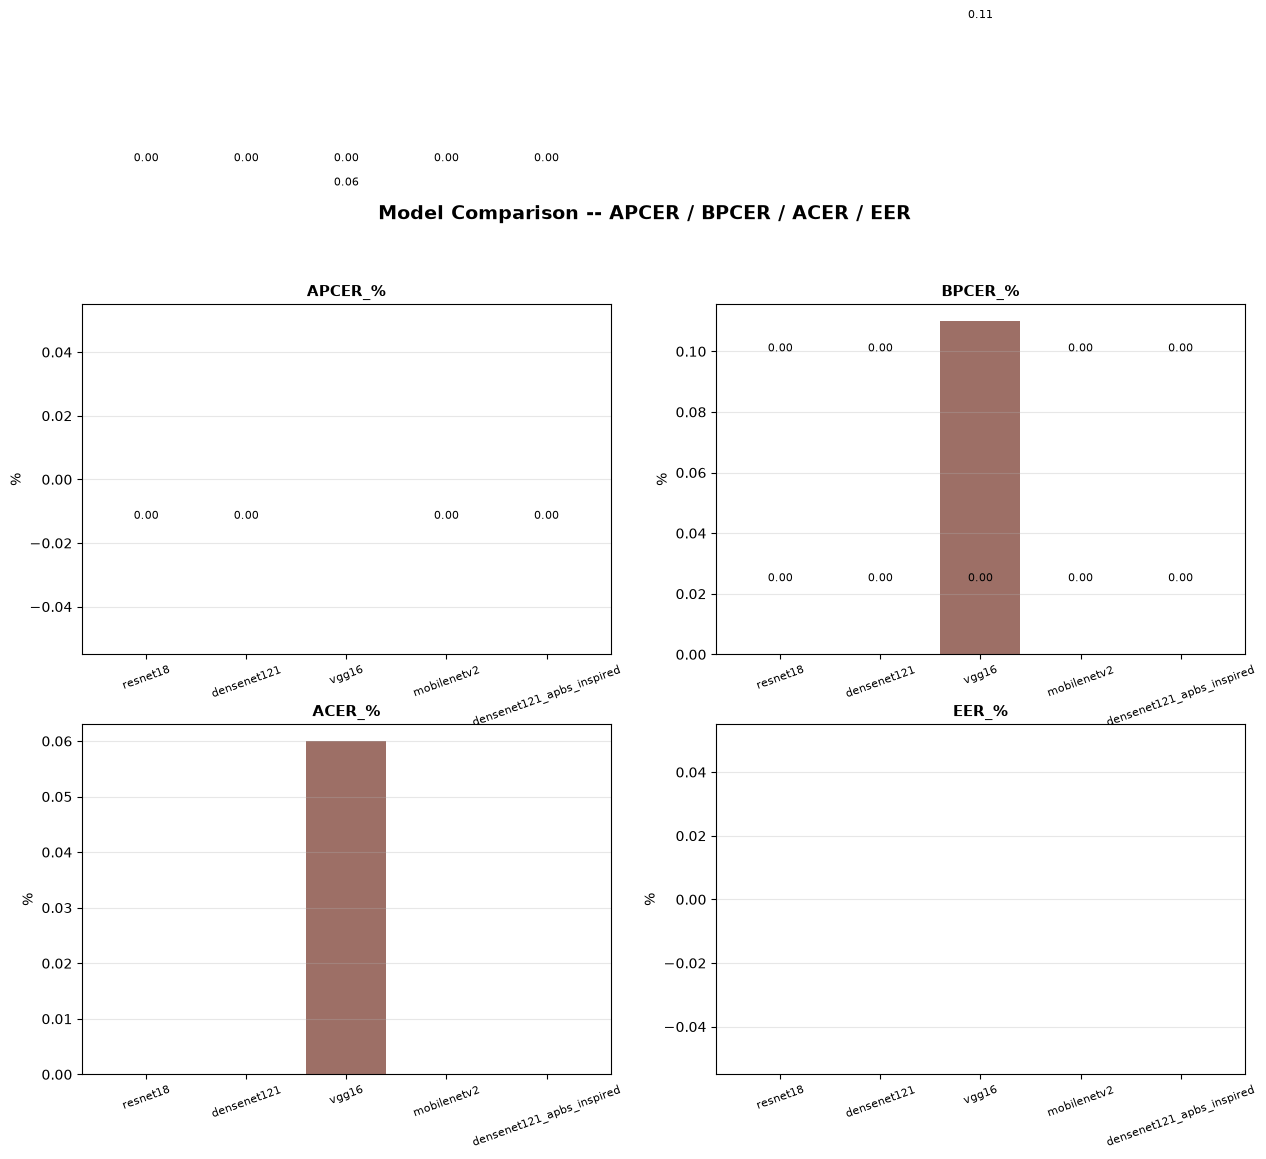

Saved -> outputs/figures/model_comparison_bars.{png,pdf}


In [39]:
# CELL 43

# -----------------------------------------------------------------------
# Final bar-chart comparison: APCER / BPCER / ACER / EER across all 5.
# -----------------------------------------------------------------------
if len(master_df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor='white')
    fig.suptitle('Model Comparison -- APCER / BPCER / ACER / EER', fontsize=14, fontweight='bold')

    metrics_to_plot = [('APCER_%', axes[0][0]), ('BPCER_%', axes[0][1]),
                       ('ACER_%', axes[1][0]), ('EER_%', axes[1][1])]
    colors_bar = plt.cm.tab10(np.linspace(0, 1, len(master_df)))

    for metric_name, ax in metrics_to_plot:
        bars = ax.bar(master_df['Backbone_key'], master_df[metric_name], color=colors_bar, alpha=0.85)
        for bar, val in zip(bars, master_df[metric_name]):
            ax.text(bar.get_x()+bar.get_width()/2, val + 0.1, f'{val:.2f}', ha='center', fontsize=8)
        ax.set_title(metric_name, fontsize=11, fontweight='bold')
        ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=20, labelsize=8); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    for ext in ['png','pdf']:
        plt.savefig(OUT_DIRS['figures'] / f'model_comparison_bars.{ext}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print('Saved -> outputs/figures/model_comparison_bars.{png,pdf}')
else:
    print('No master table -- comparison bar chart skipped.')


In [40]:
# CELL 44

# -----------------------------------------------------------------------
# Notebook A output manifest: the exact interface Notebooks B-E rely on.
# -----------------------------------------------------------------------
notebook_a_manifest = {
    'manifests': {
        'full_manifest'      : str(OUT_DIRS['manifests'] / 'full_manifest.csv'),
        'train_manifest'     : str(OUT_DIRS['manifests'] / 'train_manifest.csv'),
        'val_manifest'       : str(OUT_DIRS['manifests'] / 'val_manifest.csv'),
        'test_manifest'      : str(OUT_DIRS['manifests'] / 'test_manifest.csv'),
        'split_summary'      : str(OUT_DIRS['manifests'] / 'split_summary.csv'),
        'subject_split_map'  : str(OUT_DIRS['manifests'] / 'subject_split_map.json'),
    },
    'checkpoints': {
        name: str(OUT_DIRS['checkpoints'] / f'best_{name}_attention.pth')
        for name in BACKBONE_NAMES
    },
    'histories': {
        name: str(OUT_DIRS['histories'] / f'{name}_history.json')
        for name in BACKBONE_NAMES
    },
    'predictions': {
        name: str(OUT_DIRS['predictions'] / f'{name}_test_predictions.npz')
        for name in BACKBONE_NAMES
    },
    'metrics': {
        'all_test_metrics'        : str(OUT_DIRS['metrics'] / 'all_test_metrics.json'),
        'master_comparison_table' : str(OUT_DIRS['metrics'] / 'master_comparison_table.csv'),
        'sensor_wise_metrics'     : str(OUT_DIRS['metrics'] / 'sensor_wise_metrics.csv'),
    },
    'config'         : str(OUT_DIRS['final'] / 'config.json'),
    'preprocessing'  : str(OUT_DIRS['final'] / 'preprocessing_config.json'),
    'backbone_names' : BACKBONE_NAMES,
    'backbone_display_names': BACKBONE_DISPLAY_NAMES,
    'label_convention': {'bona_fide': 0, 'attack': 1},
    'notes': (
        'Notebook B must use canonical/original preprocessed images for TDA extraction, '
        'not the augmented train samples. Notebook C must reuse these checkpoints rather '
        'than retraining. Notebook D/E should load predictions .npz files directly rather '
        'than re-running inference where possible.'
    ),
}
with open(OUT_DIRS['final'] / 'notebook_a_manifest.json', 'w') as f:
    json.dump(notebook_a_manifest, f, indent=2)

print('Notebook A output manifest saved -> outputs/final/notebook_a_manifest.json')
print(json.dumps(notebook_a_manifest, indent=2)[:2000], '...')


Notebook A output manifest saved -> outputs/final/notebook_a_manifest.json
{
  "manifests": {
    "full_manifest": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\manifests\\full_manifest.csv",
    "train_manifest": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\manifests\\train_manifest.csv",
    "val_manifest": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\manifests\\val_manifest.csv",
    "test_manifest": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\manifests\\test_manifest.csv",
    "split_summary": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\manifests\\split_summary.csv",
    "subject_split_map": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\manifests\\subject_split_map.json"
  },
  "checkpoints": {
    "resnet18": "C:\\Users\\sahar\\OneDrive\\Desktop\\EXPLAINABLE_IRIS_PAD\\outputs\\checkpoints\\best_resnet18_attention.pth",
    "densenet121": "

In [44]:
# Proper sensor-wise ACER: shared bona_fide pool + each sensor's attack subset
# (loads directly from saved .npz -- no need to keep model objects in memory)

proper_sensor_rows = []
for backbone_name in BACKBONE_NAMES:
    npz_path = OUT_DIRS['predictions'] / f'{backbone_name}_test_predictions.npz'
    if not npz_path.exists():
        continue
    data = np.load(npz_path, allow_pickle=True)
    y_true = data['y_true']; y_pred = data['y_pred']; sensor = data['sensor']

    bf_mask_all = sensor == 'NA'   # bona fide pool (sensor-agnostic)
    for target_sensor in ['Cogent', 'Vista']:
        atk_mask = sensor == target_sensor
        combined_true = np.concatenate([y_true[bf_mask_all], y_true[atk_mask]])
        combined_pred = np.concatenate([y_pred[bf_mask_all], y_pred[atk_mask]])
        apcer, bpcer, acer = compute_apcer_bpcer_acer(combined_true, combined_pred)
        proper_sensor_rows.append({
            'Model': backbone_name, 'Sensor': target_sensor,
            'N_bona_fide': int(bf_mask_all.sum()), 'N_attack': int(atk_mask.sum()),
            'APCER_%': round(apcer*100, 2), 'BPCER_%': round(bpcer*100, 2),
            'ACER_%': round(acer*100, 2),
        })

proper_sensor_df = pd.DataFrame(proper_sensor_rows)
proper_sensor_df.to_csv(OUT_DIRS['metrics'] / 'sensor_wise_metrics_corrected.csv', index=False)
print(proper_sensor_df.to_string(index=False))

                    Model Sensor  N_bona_fide  N_attack  APCER_%  BPCER_%  ACER_%
                 resnet18 Cogent          903       176      0.0     0.00    0.00
                 resnet18  Vista          903       188      0.0     0.00    0.00
              densenet121 Cogent          903       176      0.0     0.00    0.00
              densenet121  Vista          903       188      0.0     0.00    0.00
                    vgg16 Cogent          903       176      0.0     0.11    0.06
                    vgg16  Vista          903       188      0.0     0.11    0.06
              mobilenetv2 Cogent          903       176      0.0     0.00    0.00
              mobilenetv2  Vista          903       188      0.0     0.00    0.00
densenet121_apbs_inspired Cogent          903       176      0.0     0.00    0.00
densenet121_apbs_inspired  Vista          903       188      0.0     0.00    0.00


In [43]:
# CELL 45

# -----------------------------------------------------------------------
# Final human-readable summary.
# -----------------------------------------------------------------------

if len(master_df):
    best_row = master_df.loc[master_df['ACER_%'].idxmin()]
    print(f'  Best model (lowest test ACER): {best_row["Model"]}')
    print(f'    ACER  = {best_row["ACER_%"]}%')
    print(f'    APCER = {best_row["APCER_%"]}%')
    print(f'    BPCER = {best_row["BPCER_%"]}%')
    print(f'    EER   = {best_row["EER_%"]}%')
    print(f'    AUROC = {best_row["AUROC"]}')
else:
    print('  No models were trained (dataset paths likely need to be corrected on the '
        'target machine). Re-run this notebook once NORMAL_DIR / PRINTSCAN_DIR resolve.')
print()
print('  All outputs saved under outputs/ for consumption by Notebooks B-E:')
for key, d in OUT_DIRS.items():
    n_files = len(list(d.glob('*'))) if d.exists() else 0
    print(f'    {key:15s}: {d}  ({n_files} files)')
print()



  Best model (lowest test ACER): ResNet18 + Attention Gate
    ACER  = 0.0%
    APCER = 0.0%
    BPCER = 0.0%
    EER   = 0.0%
    AUROC = 1.0

  All outputs saved under outputs/ for consumption by Notebooks B-E:
    manifests      : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\manifests  (6 files)
    audit          : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\audit  (13 files)
    augmentation   : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\augmentation  (1 files)
    checkpoints    : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\checkpoints  (5 files)
    histories      : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\histories  (6 files)
    predictions    : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\predictions  (5 files)
    metrics        : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\outputs\metrics  (3 files)
    figures        : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE